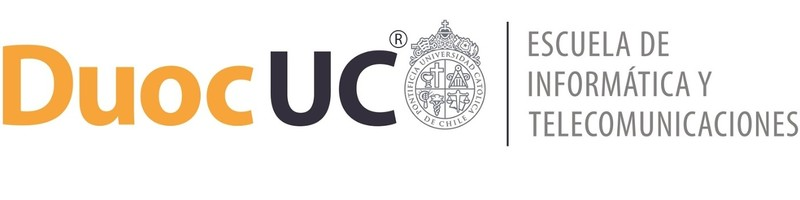

# Metodología CRISP-DM en Notebook
## Spotify Tracks: análisis exploratorio y preparación de datos

**Asignatura:** Machine Learning (MLY1101)  
**Institución:** Duoc UC  
**Evaluación:** Evaluación Parcial N.º 1  
**Integrantes:** Alejandra González, Constanza González, Diego Villar.

El proyecto estudia si los atributos medibles de audio permiten anticipar la
popularidad de una canción. Esta entrega prepara una base analítica reproducible,
realiza el análisis exploratorio y deja listo el preprocesamiento para una futura
etapa de modelamiento.


### Metodología y alcance de la entrega

| Fase CRISP-DM | Contenido | Estado en EP1 |
|---|---|---|
| 1. Business Understanding | Problema, objetivos, alcance y KPIs | Completa |
| 2. Data Understanding | Carga, estructura, calidad y exploración inicial | Completa |
| 3. Data Preparation | Limpieza, EDA posterior y pipeline de preparación | Completa |
| 4. Modeling | Entrenamiento de modelos | Trabajo futuro |
| 5. Evaluation | Métricas y comparación | Trabajo futuro |
| 6. Deployment | Puesta en producción y monitoreo | Trabajo futuro |

CRISP-DM es iterativa: si una fase descubre un problema, se puede regresar a una
fase anterior para ajustar decisiones. En esta evaluación **no se entrena ni se evalúa
un predictor**.


## Fase 1: Business Understanding

---


### 1.1 Contexto, problema de negocio, objetivos y KPIs

### Problema de negocio
Un equipo de inteligencia musical necesita determinar si los **atributos medibles de audio** de una canción permiten anticipar su nivel de popularidad para apoyar decisiones de curaduría editorial y promoción algorítmica.

### Objetivo general
Construir una base analítica reproducible para desarrollar, en una etapa futura (EP2), un modelo de **clasificación** (`RandomForestClassifier`) que asigne cada canción a un nivel de popularidad (bajo / medio / alto) a partir de sus atributos musicales. Se elige clasificación en lugar de regresión porque la correlación lineal individual entre las variables de audio y `popularidad` es débil (ver 3.7 y 3.12).

### Objetivos específicos
- **Analítico:** identificar qué atributos se asocian con mayor popularidad.
- **ML (preparación):** dejar definido y sin fuga de información el target de clasificación (`popularidad_categoria`) y el pipeline de preparación, listos para entrenar en EP2.

### KPIs
| KPI | Umbral de referencia | Estado en EP1 |
|-----|---------------------|---------------|
| Cobertura de datos (sin nulos en features) | ≥ 99% |  Verificado: 99.86% |
| Contaminación train/test (id_cancion compartidos) | 0% |  Verificado: 0 IDs |
| Accuracy (clasificación bajo/medio/alto) | > 50% (supera holgadamente al azar, 33%) |  Pendiente de modelamiento (EP2) |
| F1 macro (clasificación) | > 0.45 |  Pendiente de modelamiento (EP2) |

En esta entrega **no se entrena ni se evalúa ningún modelo**. Los KPIs de calidad de
datos (cobertura, contaminación) sí se verifican, porque son condición previa: si el
target de clasificación y el pipeline no están bien preparados, ningún resultado de
accuracy o F1 en EP2 sería confiable.


### 1.2 Fuente de datos y herramientas colaborativas

**Fuente:** Spotify_Tracks_Dataset.csv — Kaggle (*Spotify Tracks Dataset*, MaharshiPandya).

**Limitación:** sin fecha de extracción ni versión de API. La popularidad puede estar desactualizada.

| Herramienta | Uso |
|-------------|-----|
| Python / pandas / numpy | Manipulación de datos |
| matplotlib / seaborn | Visualización |
| scikit-learn | Pipeline ML |
| Jupyter Notebook | Documentación reproducible |
| Git / GitHub | Control de versiones grupal |
| Google Colab | Ejecución compartida |


### 1.3 Datos disponibles y diccionario de variables

| Variable | Tipo | Rol | Descripción |
|----------|------|-----|-------------|
| id_cancion | Texto | Identificador | ID único de Spotify — excluir del modelo |
| artistas | Texto | Metadato | Nombre(s) del artista |
| nombre_album | Texto | Metadato | Nombre del álbum |
| nombre_cancion | Texto | Metadato | Nombre de la canción |
| popularidad | Numérica (int) | **TARGET** | Popularidad 0–100 |
| duracion_ms | Numérica | Feature | Duración en ms |
| contenido_explicito | Booleana | Feature | Contenido explícito |
| bailabilidad | Float 0–1 | Feature | Aptitud para bailar |
| energia | Float 0–1 | Feature | Intensidad percibida |
| tonalidad | Categórica | Feature | Tonalidad (0=C…11=B) |
| volumen_db | Float (dB) | Feature | Volumen promedio |
| modo | Categórica | Feature | Mayor(1)/Menor(0) |
| presencia_habla | Float 0–1 | Feature | Presencia de voz hablada |
| acusticidad | Float 0–1 | Feature | Nivel acústico |
| instrumentalidad | Float 0–1 | Feature | Nivel instrumental |
| presencia_en_vivo | Float 0–1 | Feature | Presencia de audiencia en vivo |
| positividad | Float 0–1 | Feature | Positividad musical |
| tempo_bpm | Float (BPM) | Feature | Velocidad |
| compas | Categórica | Feature | Compás musical |
| genero_musical | Categórica | Feature | Género musical (cantidad calculada al ejecutar) |

> **Nota:** tonalidad, modo y compas son **códigos musicales**, no magnitudes. Se tratarán como categóricas.

### Equivalencias con el archivo original

| Original | Español |
|---|---|
| track_id | id_cancion |
| artists | artistas |
| album_name | nombre_album |
| track_name | nombre_cancion |
| popularity | popularidad |
| duration_ms | duracion_ms |
| explicit | contenido_explicito |
| danceability | bailabilidad |
| energy | energia |
| key | tonalidad |
| loudness | volumen_db |
| mode | modo |
| speechiness | presencia_habla |
| acousticness | acusticidad |
| instrumentalness | instrumentalidad |
| liveness | presencia_en_vivo |
| valence | positividad |
| tempo | tempo_bpm |
| time_signature | compas |
| track_genre | genero_musical |


### 1.4 Criterio de éxito

El éxito de esta entrega consiste en obtener una base auditable, sin nulos en las
variables que ingresarán al futuro modelo, con nombres comprensibles en español,
sin canciones compartidas entre entrenamiento y prueba, y con el target de
clasificación (`popularidad_categoria`: bajo/medio/alto) ya definido y verificado
sobre el conjunto de entrenamiento. Los umbrales de accuracy y F1 macro se
evaluarán recién después de entrenar `RandomForestClassifier` en un trabajo futuro.


## Fase 2: Data Understanding


### 2.1 Importaciones, traducción de variables y configuración

Los nombres se traducen al español desde la carga, antes de generar tablas o
gráficos. El CSV original no se modifica.


In [3]:
import sys
print(sys.executable)

c:\Users\aleee\AppData\Local\Programs\Python\Python312\python.exe


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)
# display() está disponible en Jupyter y Google Colab.
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Nombres de datos en español desde la primera lectura del CSV.
# Sin tildes ni espacios en el código; etiquetas legibles para la presentación.
COLUMNAS_ESPANOL = {
    'track_id': 'id_cancion', 'artists': 'artistas',
    'album_name': 'nombre_album', 'track_name': 'nombre_cancion',
    'popularity': 'popularidad', 'duration_ms': 'duracion_ms',
    'explicit': 'contenido_explicito', 'danceability': 'bailabilidad',
    'energy': 'energia', 'key': 'tonalidad', 'loudness': 'volumen_db',
    'mode': 'modo', 'speechiness': 'presencia_habla',
    'acousticness': 'acusticidad', 'instrumentalness': 'instrumentalidad',
    'liveness': 'presencia_en_vivo', 'valence': 'positividad',
    'tempo': 'tempo_bpm', 'time_signature': 'compas',
    'track_genre': 'genero_musical',
}
ETIQUETAS = {
    'id_cancion': 'ID de canción', 'artistas': 'Artistas',
    'nombre_album': 'Nombre del álbum', 'nombre_cancion': 'Nombre de la canción',
    'popularidad': 'Popularidad', 'duracion_ms': 'Duración (ms)',
    'duracion_min': 'Duración (min)', 'contenido_explicito': 'Contenido explícito',
    'bailabilidad': 'Bailabilidad', 'energia': 'Energía',
    'tonalidad': 'Tonalidad', 'volumen_db': 'Volumen (dB)', 'modo': 'Modo musical',
    'presencia_habla': 'Presencia de habla', 'acusticidad': 'Acusticidad',
    'instrumentalidad': 'Instrumentalidad', 'presencia_en_vivo': 'Presencia en vivo',
    'positividad': 'Positividad musical', 'tempo_bpm': 'Tempo (BPM)',
    'compas': 'Compás', 'genero_musical': 'Género musical',
}

# Opcional: indica aquí la ubicación exacta del CSV (por ejemplo, en Colab).
RUTA_DATOS = '../data/raw/Spotify_Tracks_Dataset.csv'  # Ejemplo: Path('/content/Spotify_Tracks_Dataset.csv')
carpeta_actual = Path.cwd()
PROJECT_ROOT = carpeta_actual.parent if carpeta_actual.name == 'notebooks' else carpeta_actual
candidatas = [
    PROJECT_ROOT / 'data' / 'raw' / 'Spotify_Tracks_Dataset.csv',
    carpeta_actual / 'Spotify_Tracks_Dataset.csv',
    carpeta_actual / 'upload' / 'Spotify_Tracks_Dataset.csv',
]
DATA_PATH = (Path(RUTA_DATOS).expanduser() if RUTA_DATOS is not None
             else next((p for p in candidatas if p.is_file()), candidatas[0]))
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
IMAGES_DIR = PROJECT_ROOT / 'images'
print('Proyecto:', PROJECT_ROOT)
print('Dataset:', DATA_PATH)


Proyecto: c:\Users\aleee\Downloads\machine-learning-spotify
Dataset: ..\data\raw\Spotify_Tracks_Dataset.csv


### 2.2 Carga del dataset

El notebook busca Spotify_Tracks_Dataset.csv en data/raw/, junto al notebook o
en upload/. En el caso de Google Colab también se puede indicar la ruta exacta mediante
RUTA_DATOS.


In [5]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f'No se encontró {DATA_PATH}. Agrega Spotify_Tracks_Dataset.csv en '
        'data/raw/ o junto al notebook, o configura RUTA_DATOS en la sección 0.'
    )

# Renombrar ANTES de cualquier head(), tabla o gráfico.
df_crudo = pd.read_csv(DATA_PATH).rename(columns=COLUMNAS_ESPANOL)
df_crudo = df_crudo.drop(columns=['Unnamed: 0'], errors='ignore')
faltan_columnas = sorted(set(COLUMNAS_ESPANOL.values()) - set(df_crudo.columns))
if faltan_columnas:
    raise ValueError(f'Faltan columnas requeridas en el CSV: {faltan_columnas}')
if df_crudo.columns.duplicated().any():
    raise ValueError('Hay nombres de columna duplicados después de traducir.')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Datos cargados: {len(df_crudo):,} filas × {df_crudo.shape[1]} columnas útiles')
display(df_crudo.head(3))


Datos cargados: 114,000 filas × 20 columnas útiles


,id_cancion,artistas,nombre_album,nombre_cancion,popularidad,duracion_ms,contenido_explicito,bailabilidad,energia,tonalidad,volumen_db,modo,presencia_habla,acusticidad,instrumentalidad,presencia_en_vivo,positividad,tempo_bpm,compas,genero_musical
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.6760,0.4610,1,-6.7460,0,0.1430,0.0322,0.0000,0.3580,0.7150,87.9170,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.4200,0.1660,1,-17.2350,1,0.0763,0.9240,0.0000,0.1010,0.2670,77.4890,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.4380,0.3590,0,-9.7340,1,0.0557,0.2100,0.0000,0.1170,0.1200,76.3320,4,acoustic


### 2.3 Estructura y tipos de datos

Se revisan el tipo de dato, los registros no nulos, los nulos explícitos y la
cantidad de valores únicos de cada variable.


In [6]:
# Inspección de estructura
estructura = pd.DataFrame({
    'variable': df_crudo.columns,
    'tipo_dato':    df_crudo.dtypes.astype(str).values,
    'no_nulos': df_crudo.notna().sum().values,
    'nulos':    df_crudo.isna().sum().values,
    'unicos':   df_crudo.nunique(dropna=True).values
})
display(estructura)


,variable,tipo_dato,no_nulos,nulos,unicos
0,id_cancion,object,114000,0,89741
1,artistas,object,113999,1,31437
2,nombre_album,object,113999,1,46589
3,nombre_cancion,object,113999,1,73608
4,popularidad,int64,114000,0,101
5,duracion_ms,int64,114000,0,50697
6,contenido_explicito,bool,114000,0,2
7,bailabilidad,float64,114000,0,1174
8,energia,float64,114000,0,2083
9,tonalidad,int64,114000,0,12


### 2.4 Auditoría inicial de calidad

La auditoría distingue nulos explícitos, cadenas ?, textos vacíos y ceros. Los
conteos por indicador describen incidencias y no se suman como si fueran filas
únicas, porque un mismo registro puede presentar más de un problema.


,nulos_explicitos,interrogaciones,vacios,ceros
variable,,,,
artistas,1,0,0,0
nombre_album,1,20,0,0
nombre_cancion,1,0,0,0
tempo_bpm,0,0,0,157
bailabilidad,0,0,0,157
energia,0,0,0,1
compas,0,0,0,163
duracion_ms,0,0,0,1


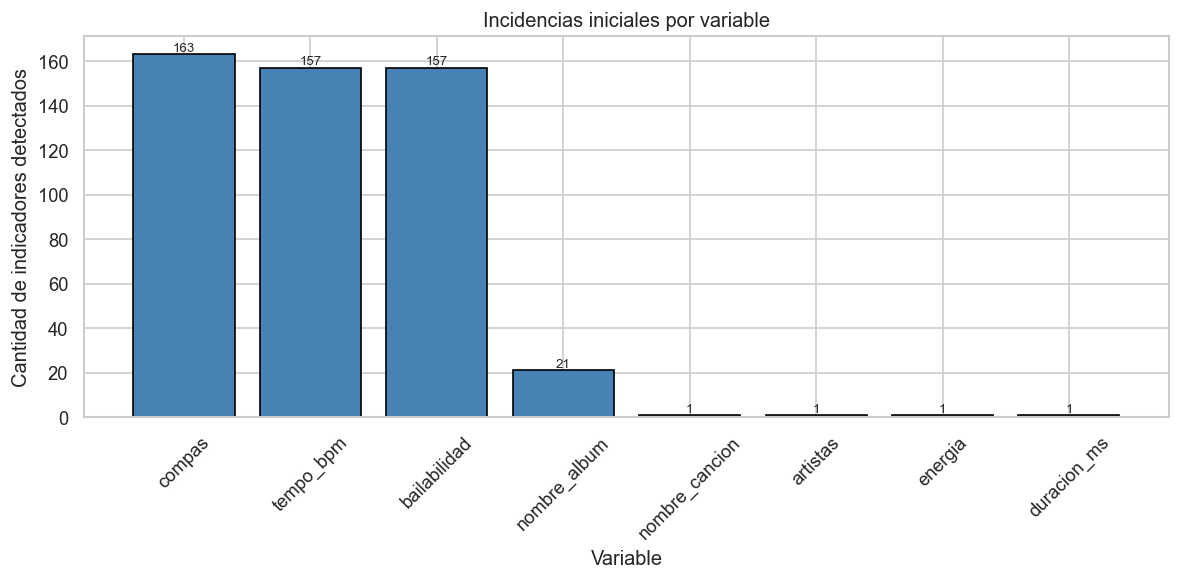

In [7]:
textos_auditoria = ['artistas', 'nombre_album', 'nombre_cancion']
numericas_cero = ['tempo_bpm', 'bailabilidad', 'energia', 'compas', 'duracion_ms']

auditoria_inicial = pd.DataFrame(index=textos_auditoria + numericas_cero)
auditoria_inicial.index.name = 'variable'
auditoria_inicial['nulos_explicitos'] = df_crudo[auditoria_inicial.index].isna().sum()
auditoria_inicial['interrogaciones'] = 0
auditoria_inicial['vacios'] = 0
auditoria_inicial['ceros'] = 0

for columna in textos_auditoria:
    texto = df_crudo[columna].astype('string').str.strip()
    auditoria_inicial.loc[columna, 'interrogaciones'] = int(texto.eq('?').sum())
    auditoria_inicial.loc[columna, 'vacios'] = int(texto.eq('').sum())

for columna in numericas_cero:
    valores = pd.to_numeric(df_crudo[columna], errors='coerce')
    auditoria_inicial.loc[columna, 'ceros'] = int(valores.eq(0).sum())

display(auditoria_inicial)

incidencias_por_variable = auditoria_inicial.sum(axis=1).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(incidencias_por_variable.index, incidencias_por_variable.values,
       color='steelblue', edgecolor='black')
ax.set_title('Incidencias iniciales por variable')
ax.set_xlabel('Variable')
ax.set_ylabel('Cantidad de indicadores detectados')
ax.tick_params(axis='x', rotation=45)
for barra, valor in zip(ax.patches, incidencias_por_variable.values):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height(),
            f'{int(valor):,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '00_calidad_datos_crudos.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.5 Estadística y distribución preliminar

Esta revisión se realiza sobre los datos crudos. Su finalidad es comprender la
fuente y detectar problemas; las cifras definitivas para presentación se vuelven
a calcular después de la limpieza en la Fase 3.


,count,mean,std,min,25%,50%,75%,max
popularidad,"114,000.0000",33.2385,22.3051,0.0000,17.0000,35.0000,50.0000,100.0000
duracion_ms,"114,000.0000","228,029.1531","107,297.7126",0.0000,"174,066.0000","212,906.0000","261,506.0000","5,237,295.0000"
bailabilidad,"114,000.0000",0.5668,0.1735,0.0000,0.4560,0.5800,0.6950,0.9850
energia,"114,000.0000",0.6414,0.2515,0.0000,0.4720,0.6850,0.8540,1.0000
volumen_db,"114,000.0000",-8.2590,5.0293,-49.5310,-10.0130,-7.0040,-5.0030,4.5320
presencia_habla,"114,000.0000",0.0847,0.1057,0.0000,0.0359,0.0489,0.0845,0.9650
acusticidad,"114,000.0000",0.3149,0.3325,0.0000,0.0169,0.1690,0.5980,0.9960
instrumentalidad,"114,000.0000",0.1560,0.3096,0.0000,0.0000,0.0000,0.0490,1.0000
presencia_en_vivo,"114,000.0000",0.2136,0.1904,0.0000,0.0980,0.1320,0.2730,1.0000
positividad,"114,000.0000",0.4741,0.2593,0.0000,0.2600,0.4640,0.6830,0.9950


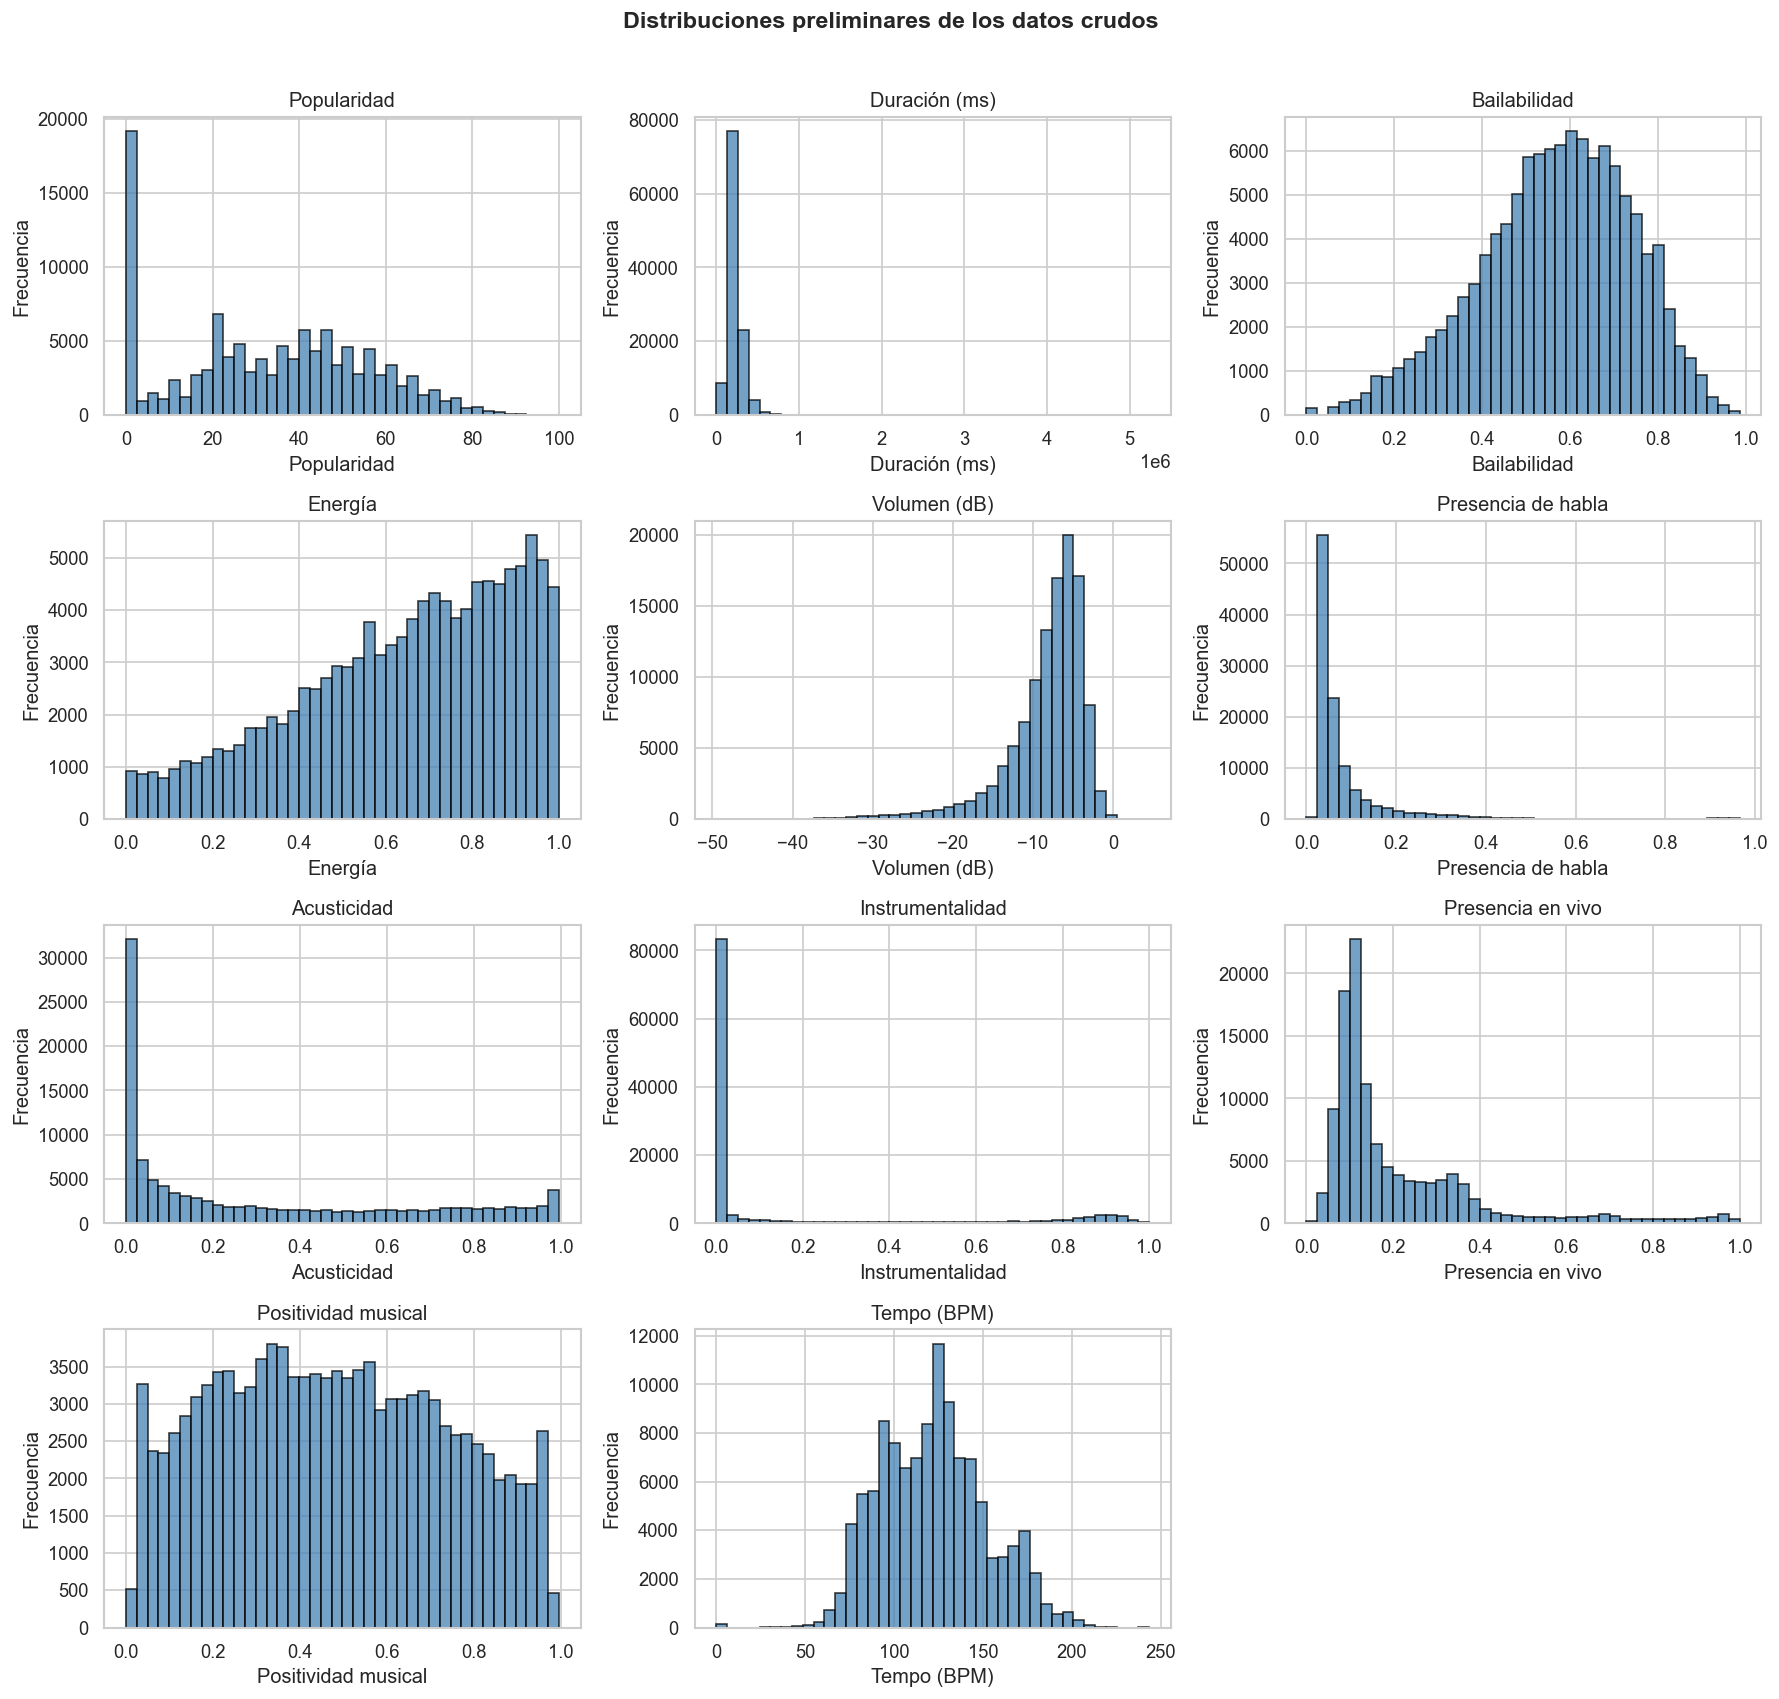

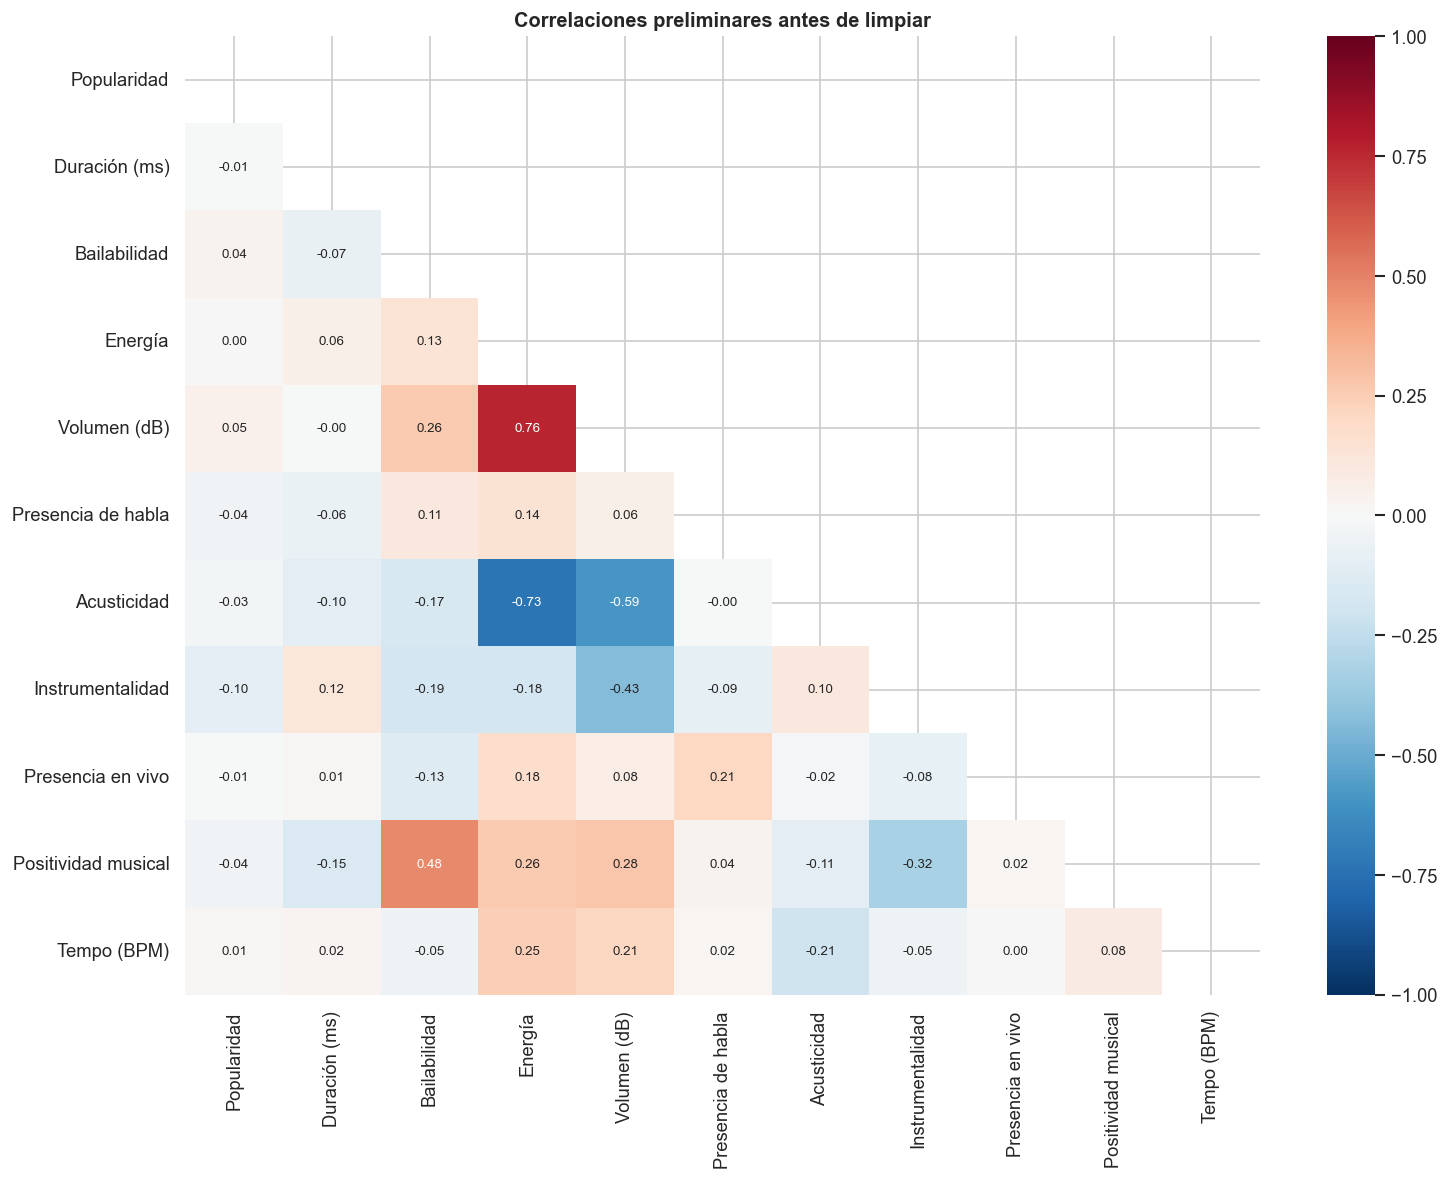

Filas originales: 114,000
Columnas útiles: 20
Duplicados exactos: 450
Canciones únicas por ID: 89,741


In [8]:
numericas_crudas = [
    'popularidad', 'duracion_ms', 'bailabilidad', 'energia', 'volumen_db',
    'presencia_habla', 'acusticidad', 'instrumentalidad',
    'presencia_en_vivo', 'positividad', 'tempo_bpm'
]

display(df_crudo[numericas_crudas].describe().T.round(4))

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()
for i, columna in enumerate(numericas_crudas):
    valores = pd.to_numeric(df_crudo[columna], errors='coerce').dropna()
    axes[i].hist(valores, bins=40, color='steelblue', edgecolor='black', alpha=0.75)
    axes[i].set_title(ETIQUETAS[columna])
    axes[i].set_xlabel(ETIQUETAS[columna])
    axes[i].set_ylabel('Frecuencia')
for j in range(len(numericas_crudas), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribuciones preliminares de los datos crudos',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '00_distribuciones_crudas.png', dpi=150, bbox_inches='tight')
plt.show()

correlacion_cruda = df_crudo[numericas_crudas].corr()
fig, ax = plt.subplots(figsize=(13, 10))
mascara = np.triu(np.ones_like(correlacion_cruda, dtype=bool))
sns.heatmap(
    correlacion_cruda.rename(index=ETIQUETAS, columns=ETIQUETAS),
    mask=mascara, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlaciones preliminares antes de limpiar', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Filas originales: {len(df_crudo):,}')
print(f'Columnas útiles: {df_crudo.shape[1]:,}')
print(f'Duplicados exactos: {df_crudo.duplicated().sum():,}')
print(f'Canciones únicas por ID: {df_crudo["id_cancion"].nunique(dropna=True):,}')


## Conclusiones Fase 2

- El dataset combina metadatos, variables numéricas de audio, categorías musicales
  y la variable objetivo popularidad.
- La auditoría separa los distintos tipos de incidencia para evitar confundir un
  cero con un nulo explícito.
- Los gráficos y tablas anteriores permiten observar forma, dispersión, valores
  extremos y asociaciones iniciales.
- Los valores calculados en esta fase no se utilizan todavía como entrada de un
  modelo. Primero se aplican las reglas documentadas de la Fase 3.
- La correlación describe asociación lineal; no demuestra causalidad ni garantiza
  desempeño predictivo.


## Fase 3: Data Preparation


### 3.1 Limpieza y transformaciones justificadas

| Variables en español | Condición | Tratamiento |
|---|---|---|
| artistas, nombre_cancion | Nulo, vacío o «?» | Eliminar la fila |
| nombre_album | Nulo, vacío o «?» | Imputar DESCONOCIDO en las filas conservadas |
| tempo_bpm, bailabilidad, energia | Al menos una igual a cero | Eliminar la fila una sola vez |
| Las tres métricas anteriores | Nulo explícito | Eliminar, sin KNN en esta versión |
| compas | Cero o nulo | Moda de los valores observados **solo en entrenamiento** |
| duracion_ms | Cero, negativo o nulo | Eliminar la fila |

- "?" y espacios vacíos se normalizan solo en los tres metadatos de texto.
- No se asigna SINGLE: la falta de nombre no demuestra que un lanzamiento sea un single.
- Los conteos informados (1 nulo de texto, 20 "?", 157 ceros de audio, 163 compases
  cero y 1 duración cero) son referencias a comprobar. Las filas pueden coincidir;
  **no se suman los conteos para calcular las eliminaciones**.
- Eliminar ceros de bailabilidad y energía es una **decisión de este proyecto**:
  cero pertenece a sus escalas y no demuestra un dato faltante. Puede sesgar la
  muestra hacia canciones más bailables y enérgicas.
- Se mantienen los ceros válidos de otras variables, como popularidad, modo,
  tonalidad e instrumentalidad.
- No se usa KNNImputer para compás: su promedio podría crear categorías
  fraccionarias. La moda conserva un valor observado; en empate se elige el menor.
- Los compases observados positivos se conservan si son enteros. Las categorías
  inusuales se reportan para revisión, sin inventar valores ni truncar decimales.
- Los valores extremos detectados por IQR se reportan; no se eliminan por IQR.

La partición por canción se reserva aquí para aprender la moda sin consultar el
conjunto de prueba. df_base conserva el compás sin imputar para el pipeline;
df_limpio incorpora esa moda para EDA y exportación. En EP2 se debe volver a
ajustar el pipeline dentro de cada pliegue de validación usando df_base.

Referencias: [escalas de audio de Spotify](https://developer.spotify.com/documentation/web-api/reference/get-audio-features),
[moda con SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html).


In [9]:
def limpiar_spotify(datos, semilla=42):
    """Limpieza auditable, sin modificar la entrada ni aprender del test."""
    df = datos.copy()
    textos = ['artistas', 'nombre_album', 'nombre_cancion']
    audio_cero = ['tempo_bpm', 'bailabilidad', 'energia']

    # Diagnóstico ANTES de eliminar filas: separa nulos, ? y ceros.
    auditoria = pd.DataFrame(index=textos + audio_cero + ['compas', 'duracion_ms'])
    auditoria.index.name = 'variable'
    auditoria['nulos_explicitos'] = df[auditoria.index].isna().sum()
    auditoria['interrogaciones'] = 0
    auditoria['vacios'] = 0
    auditoria['ceros'] = 0
    for col in textos:
        texto = df[col].astype('string').str.strip()
        auditoria.loc[col, 'interrogaciones'] = int(texto.eq('?').sum())
        auditoria.loc[col, 'vacios'] = int(texto.eq('').sum())
        df[col] = texto.mask(texto.isin(['', '?']), pd.NA)
    for col in audio_cero + ['compas', 'duracion_ms']:
        df[col] = pd.to_numeric(df[col], errors='raise').astype(float)
        auditoria.loc[col, 'ceros'] = int(df[col].eq(0).sum())

    motivos = pd.DataFrame({
        'artista_o_cancion_faltante': df[['artistas', 'nombre_cancion']].isna().any(axis=1),
        'cero_en_audio': df[audio_cero].eq(0).any(axis=1),
        'nulo_en_audio': df[audio_cero].isna().any(axis=1),
        'duracion_invalida': df['duracion_ms'].isna() | df['duracion_ms'].le(0),
    }, index=df.index)
    eliminar = motivos.any(axis=1)
    resumen = pd.DataFrame({
        'criterio': motivos.columns,
        'filas_afectadas_pueden_coincidir': motivos.sum().values,
    })
    # Una fila con varias incidencias se elimina solo una vez.
    base = df.loc[~eliminar].copy()
    if base.empty:
        raise ValueError('No quedan filas después de la limpieza; revisa las incidencias.')
    albumes_imputados = int(base['nombre_album'].isna().sum())
    base['nombre_album'] = base['nombre_album'].fillna('DESCONOCIDO')
    base['compas'] = base['compas'].mask(base['compas'].eq(0), np.nan)
    observados = base['compas'].dropna()
    if ((observados <= 0) | ~np.isfinite(observados) | (observados % 1 != 0)).any():
        raise ValueError('Hay compases negativos, no finitos o decimales. Revisarlos sin truncar.')
    base['duracion_min'] = base['duracion_ms'] / 60000

    ids = base['id_cancion'].astype('string').str.strip()
    if ids.isna().any() or ids.isin(['', '?']).any():
        raise ValueError('Hay identificadores de canción faltantes; no se puede agrupar con seguridad.')
    base['id_cancion'] = ids
    if ids.nunique() < 2:
        raise ValueError('Se necesitan al menos dos canciones distintas para separar entrenamiento y prueba.')
    divisor = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=semilla)
    idx_entrenamiento, idx_prueba = next(divisor.split(base, groups=ids))
    compas_entrenamiento = base.iloc[idx_entrenamiento][['compas']]
    if compas_entrenamiento['compas'].notna().sum() == 0:
        raise ValueError('No hay compases observados en entrenamiento para calcular la moda.')
    imputador = SimpleImputer(strategy='most_frequent')
    imputador.fit(compas_entrenamiento)
    moda = int(imputador.statistics_[0])
    limpio = base.copy()
    limpio['compas'] = imputador.transform(base[['compas']]).ravel().astype('int64')

    particion = pd.Series('prueba', index=base.index, name='particion')
    particion.iloc[idx_entrenamiento] = 'entrenamiento'
    imputaciones = pd.DataFrame({
        'particion': particion,
        'compas_imputado': base['compas'].isna(),
    }).groupby('particion')['compas_imputado'].sum().astype(int)
    balance = pd.DataFrame({
        'indicador': ['filas_originales', 'filas_eliminadas_sin_duplicar', 'filas_conservadas',
                      'albumes_imputados_en_filas_conservadas', 'compases_imputados',
                      'moda_compas_entrenamiento'],
        'cantidad': [len(df), int(eliminar.sum()), len(limpio), albumes_imputados,
                     int(base['compas'].isna().sum()), moda],
    })
    descartadas = datos.loc[eliminar].join(motivos.loc[eliminar].add_prefix('motivo_'))
    return base, limpio, idx_entrenamiento, idx_prueba, auditoria, resumen, balance, imputaciones, descartadas

(df_base, df_limpio, train_idx, test_idx, auditoria_faltantes, resumen_eliminacion,
 balance_limpieza, imputaciones_compas, filas_descartadas) = limpiar_spotify(df_crudo)

display(auditoria_faltantes)
display(resumen_eliminacion)
display(balance_limpieza)
display(imputaciones_compas.to_frame('cantidad_imputada'))
perdida_pct = 100 * (len(df_crudo) - len(df_limpio)) / len(df_crudo)
print(f'Pérdida real de filas: {perdida_pct:.4f}% (sin duplicar coincidencias)')

# Guardar datos limpios, base sin imputación aprendida y trazabilidad.
df_limpio.to_csv(PROCESSED_DIR / 'spotify_clean.csv', index=False)
df_base.to_csv(PROCESSED_DIR / 'spotify_base_modelo.csv', index=False)
auditoria_faltantes.to_csv(PROCESSED_DIR / 'auditoria_faltantes.csv')
resumen_eliminacion.to_csv(PROCESSED_DIR / 'resumen_eliminacion.csv', index=False)
balance_limpieza.to_csv(PROCESSED_DIR / 'balance_limpieza.csv', index=False)
filas_descartadas.to_csv(PROCESSED_DIR / 'filas_descartadas.csv', index_label='indice_origen')
particion = pd.DataFrame({'id_cancion': df_base['id_cancion'], 'particion': 'prueba'})
particion.iloc[train_idx, particion.columns.get_loc('particion')] = 'entrenamiento'
particion.to_csv(PROCESSED_DIR / 'particion_modelo.csv', index_label='indice_origen')
print('Datos y auditoría guardados; todos los nombres de columna están en español.')


,nulos_explicitos,interrogaciones,vacios,ceros
variable,,,,
artistas,1,0,0,0
nombre_album,1,20,0,0
nombre_cancion,1,0,0,0
tempo_bpm,0,0,0,157
bailabilidad,0,0,0,157
energia,0,0,0,1
compas,0,0,0,163
duracion_ms,0,0,0,1


,criterio,filas_afectadas_pueden_coincidir
0,artista_o_cancion_faltante,1
1,cero_en_audio,157
2,nulo_en_audio,0
3,duracion_invalida,1


,indicador,cantidad
0,filas_originales,114000
1,filas_eliminadas_sin_duplicar,158
2,filas_conservadas,113842
3,albumes_imputados_en_filas_conservadas,20
4,compases_imputados,6
5,moda_compas_entrenamiento,4


,cantidad_imputada
particion,
entrenamiento,4
prueba,2


Pérdida real de filas: 0.1386% (sin duplicar coincidencias)
Datos y auditoría guardados; todos los nombres de columna están en español.


In [10]:
# Clasificación de variables para el análisis
audio_numericas = [
    'duracion_ms', 'bailabilidad', 'energia', 'volumen_db', 'presencia_habla',
    'acusticidad', 'instrumentalidad', 'presencia_en_vivo', 'positividad', 'tempo_bpm'
]
variables_categoricas = ['contenido_explicito', 'tonalidad', 'modo', 'compas', 'genero_musical']
metadatos_texto        = ['id_cancion', 'artistas', 'nombre_album', 'nombre_cancion']
numericas_descriptivas = ['popularidad', 'duracion_ms', 'duracion_min'] + audio_numericas[1:]

print('Numéricas predictoras:', audio_numericas)
print('Categóricas predictoras:', variables_categoricas)
print('Metadatos (excluir del modelo):', metadatos_texto)

Numéricas predictoras: ['duracion_ms', 'bailabilidad', 'energia', 'volumen_db', 'presencia_habla', 'acusticidad', 'instrumentalidad', 'presencia_en_vivo', 'positividad', 'tempo_bpm']
Categóricas predictoras: ['contenido_explicito', 'tonalidad', 'modo', 'compas', 'genero_musical']
Metadatos (excluir del modelo): ['id_cancion', 'artistas', 'nombre_album', 'nombre_cancion']


### 3.2 Estadística descriptiva posterior a la limpieza

Se calculan media, mediana, desviación estándar, percentiles 25/50/75/90/95/99, rango, skewness y curtosis para cada variable numérica.


In [11]:
# Estadística descriptiva extendida con skewness y curtosis
rows = []
for col in numericas_descriptivas:
    s = df_limpio[col].dropna()
    q25, q50, q75, q90, q95, q99 = s.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    rows.append({
        'variable':   col,
        'cantidad':      int(len(s)),
        'media':       s.mean(),
        'mediana':     s.median(),
        'desviacion_estandar':        s.std(),
        'minimo':        s.min(),
        'P25':        q25,
        'P75':        q75,
        'P90':        q90,
        'P95':        q95,
        'P99':        q99,
        'maximo':        s.max(),
        'rango':      s.max() - s.min(),
        'asimetria':   s.skew(),
        'curtosis':   s.kurtosis()
    })

stats_df = pd.DataFrame(rows).set_index('variable')
display(stats_df.round(4))
stats_df.to_csv(PROCESSED_DIR / 'descriptive_statistics.csv')
print('Estadísticas guardadas.')

,cantidad,media,mediana,desviacion_estandar,minimo,P25,P75,P90,P95,P99,maximo,rango,asimetria,curtosis
variable,,,,,,,,,,,,,,
popularidad,113842,33.2334,34.0000,22.3161,0.0000,17.0000,50.0000,63.0000,69.0000,80.0000,100.0000,100.0000,0.0469,-0.9297
duracion_ms,113842,"228,108.6597","213,000.0000","106,306.2429","15,800.0000","174,198.5000","261,583.0000","327,835.0000","387,168.9000","530,665.8100","5,237,295.0000","5,221,495.0000",10.9655,351.1657
duracion_min,113842,3.8018,3.5500,1.7718,0.2633,2.9033,4.3597,5.4639,6.4528,8.8444,87.2882,87.0249,10.9655,351.1657
bailabilidad,113842,0.5676,0.5800,0.1724,0.0513,0.4560,0.6950,0.7840,0.8240,0.9010,0.9850,0.9337,-0.3728,-0.2584
energia,113842,0.6421,0.6850,0.2508,0.0000,0.4730,0.8540,0.9410,0.9690,0.9930,1.0000,1.0000,-0.5941,-0.5309
volumen_db,113842,-8.2399,-6.9980,4.9937,-46.5910,-10.0020,-5.0000,-3.6770,-2.9731,-1.6340,4.5320,51.1230,-1.9861,5.7514
presencia_habla,113842,0.0848,0.0490,0.1058,0.0221,0.0359,0.0846,0.1760,0.2680,0.5070,0.9650,0.9429,4.6479,28.8154
acusticidad,113842,0.3147,0.1680,0.3323,0.0000,0.0169,0.5970,0.8660,0.9480,0.9920,0.9960,0.9960,0.7280,-0.9481
instrumentalidad,113842,0.1554,0.0000,0.3089,0.0000,0.0000,0.0477,0.8310,0.9040,0.9540,1.0000,1.0000,1.7403,1.2918


Estadísticas guardadas.


#### Interpretación de la tabla actualizada

Las cifras deben salir de la ejecución actual, porque la eliminación de ceros
cambia medias, percentiles y correlaciones. Comparar media y mediana permite
describir la distribución; asimetría y curtosis ayudan a revisar valores extremos.

No confundir una correlación débil con la imposibilidad de predecir: pueden existir
relaciones no lineales o interacciones. El rendimiento se comprobará en EP2.


### 3.3 Histogramas y distribuciones

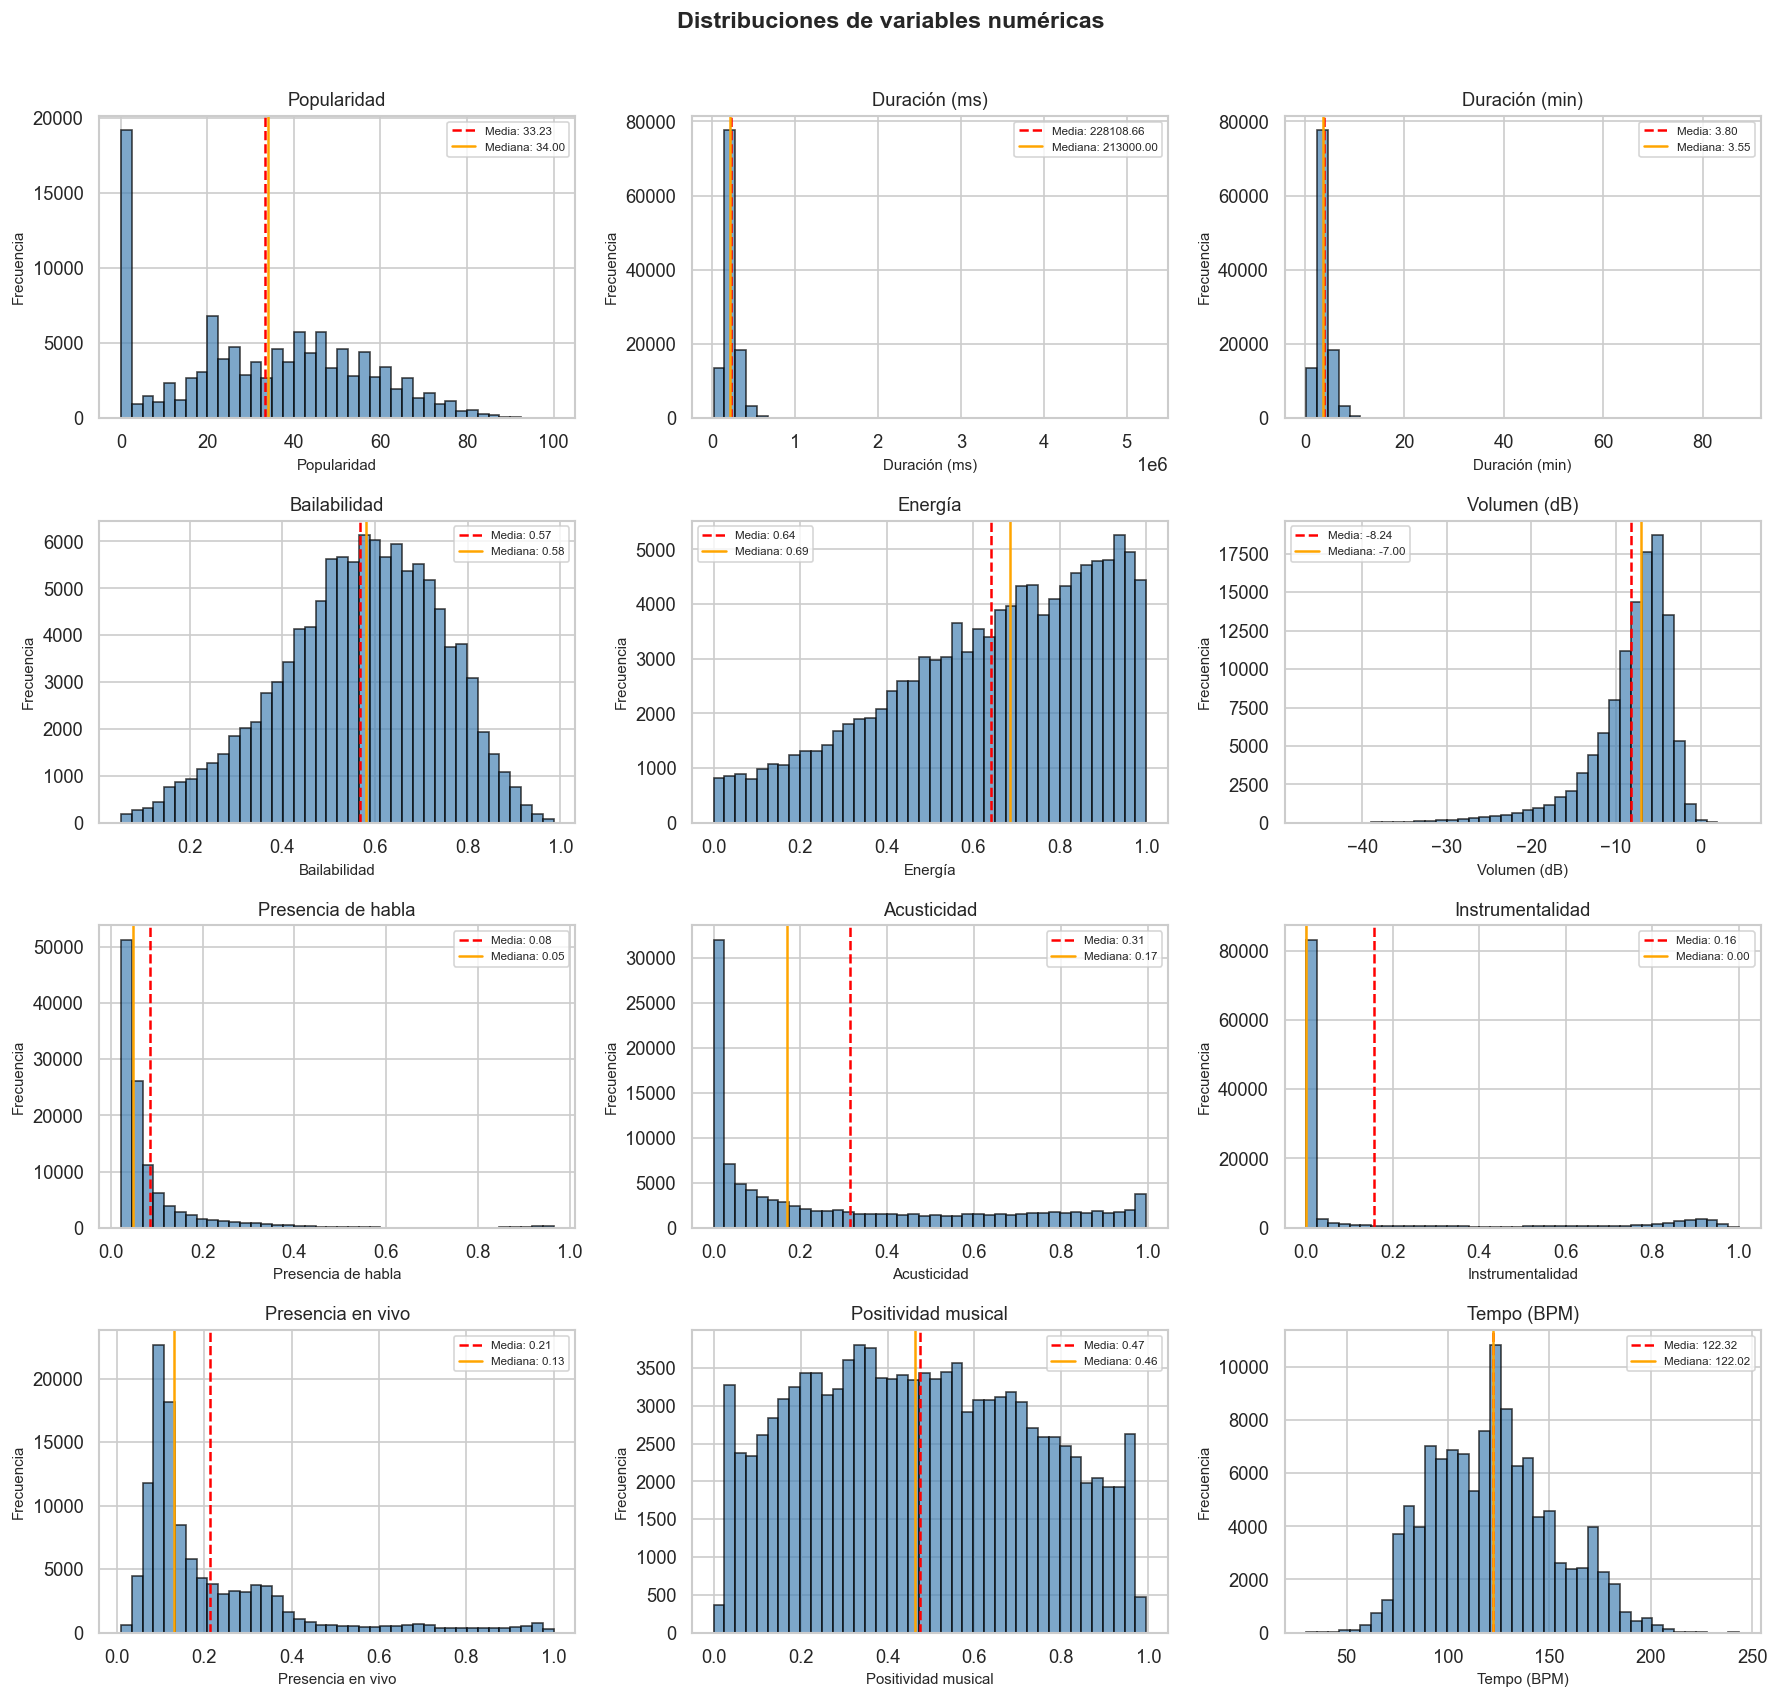

Gráfico guardado: 01_histogramas_numericas.png


In [12]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(numericas_descriptivas):
    ax = axes[i]
    data = df_limpio[col].dropna()
    ax.hist(data, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(ETIQUETAS[col], fontsize=11)
    ax.set_xlabel(ETIQUETAS[col], fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    # Añadir líneas de media y mediana
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Media: {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='-',  linewidth=1.5, label=f'Mediana: {data.median():.2f}')
    ax.legend(fontsize=7)

# Ocultar subplots vacíos
for j in range(len(numericas_descriptivas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de variables numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '01_histogramas_numericas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: 01_histogramas_numericas.png')


### 3.4 Variables categóricas: frecuencias y proporciones

Se analiza la distribución de contenido_explicito, tonalidad, modo, compas y genero_musical.


In [13]:
def tabla_frecuencias(data, variable):
    counts = data[variable].value_counts(dropna=False)
    pct    = data[variable].value_counts(dropna=False, normalize=True) * 100
    return pd.DataFrame({'frecuencia': counts, 'proporcion_pct': pct.round(2)})

for variable in ['contenido_explicito', 'tonalidad', 'modo', 'compas']:
    print(f'\n── {variable} ──')
    display(tabla_frecuencias(df_limpio, variable))

print(f'\n── genero_musical: {df_limpio["genero_musical"].nunique()} géneros únicos (mostrando top 20) ──')
display(tabla_frecuencias(df_limpio, 'genero_musical').head(20))



── contenido_explicito ──


,frecuencia,proporcion_pct
contenido_explicito,,
False,104095,91.4400
True,9747,8.5600



── tonalidad ──


,frecuencia,proporcion_pct
tonalidad,,
7,13236,11.6300
0,13045,11.4600
2,11625,10.2100
9,11303,9.9300
1,10743,9.4400
5,9362,8.2200
11,9273,8.1500
4,9004,7.9100
6,7914,6.9500



── modo ──


,frecuencia,proporcion_pct
modo,,
1,72573,63.7500
0,41269,36.2500



── compas ──


,frecuencia,proporcion_pct
compas,,
4,101848,89.4600
3,9195,8.0800
5,1826,1.6000
1,973,0.8500



── genero_musical: 114 géneros únicos (mostrando top 20) ──


,frecuencia,proporcion_pct
genero_musical,,
acoustic,1000,0.8800
afrobeat,1000,0.8800
alt-rock,1000,0.8800
alternative,1000,0.8800
anime,1000,0.8800
black-metal,1000,0.8800
blues,1000,0.8800
bluegrass,1000,0.8800
brazil,1000,0.8800


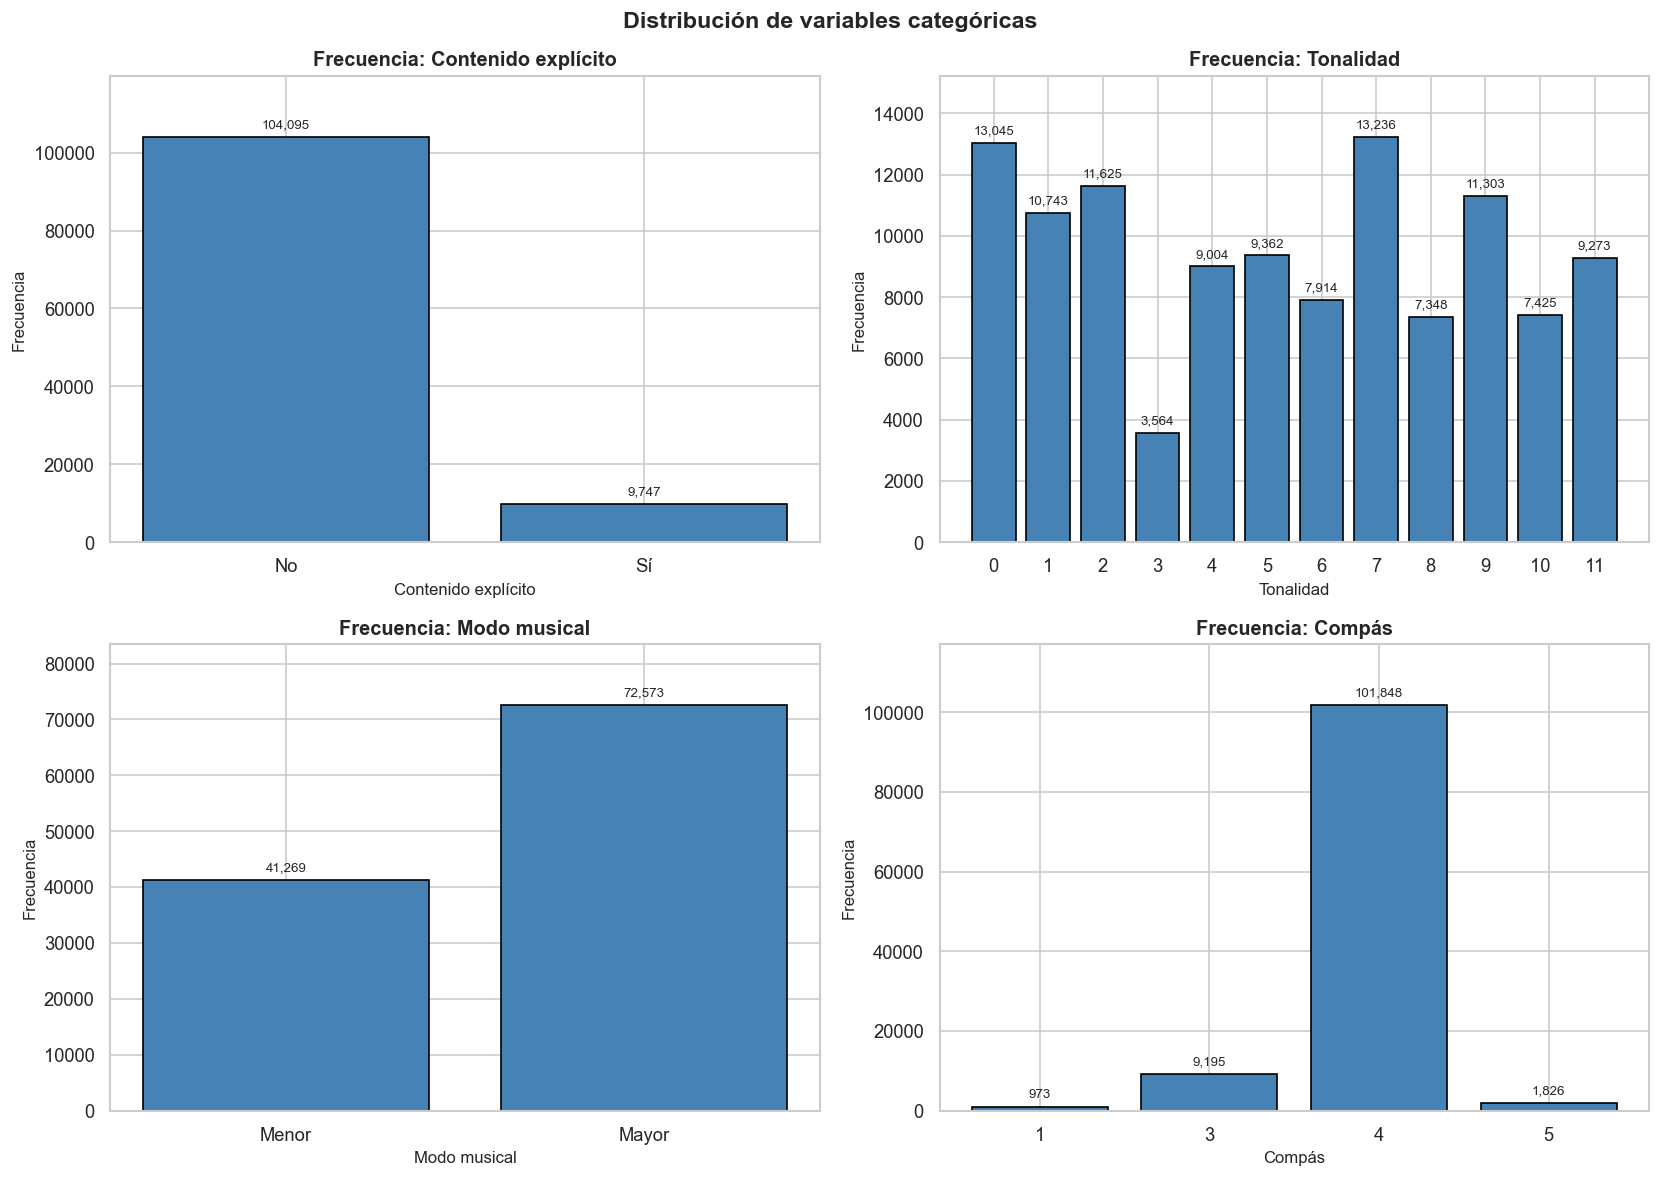

In [14]:
# Gráficos de variables categóricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, variable in zip(axes.flatten(), ['contenido_explicito', 'tonalidad', 'modo', 'compas']):
    counts = df_limpio[variable].value_counts().sort_index()
    ax.bar([({False: 'No', True: 'Sí'}.get(v, str(v)) if variable == 'contenido_explicito'
            else {0: 'Menor', 1: 'Mayor'}.get(v, str(v)) if variable == 'modo'
            else str(v)) for v in counts.index], counts.values, color='steelblue', edgecolor='black')
    ax.set_title(f'Frecuencia: {ETIQUETAS[variable]}', fontsize=12, fontweight='bold')
    ax.set_xlabel(ETIQUETAS[variable], fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.set_ylim(0, max(1, counts.max()) * 1.15)
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max() * 0.015,
                f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribución de variables categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '02_variables_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 Validación de calidad, dominios y duplicados

Se comprueba el resultado de la limpieza y se reportan valores inusuales. Las
reglas específicas del proyecto se distinguen de los dominios de las variables.
Los compases 1 y 2, si aparecen en el CSV histórico, se conservan como categorías
observadas pero se señalan: la documentación actual de Spotify describe 3–7.


In [15]:
checks = {
    'Nulos después de limpiar (todas las columnas)': int(df_limpio.isna().sum().sum()),
    'Artista o canción vacíos / interrogación': int(df_limpio[['artistas', 'nombre_cancion']].isin(['', '?']).sum().sum()),
    'Álbum vacío / interrogación': int(df_limpio['nombre_album'].isin(['', '?']).sum()),
    'Popularidad fuera de 0–100': int((~df_limpio['popularidad'].between(0, 100)).sum()),
    'Tonalidad fuera de códigos -1 a 11': int((~df_limpio['tonalidad'].isin(range(-1, 12))).sum()),
    'Modo fuera de {0, 1}': int((~df_limpio['modo'].isin([0, 1])).sum()),
    'Duración no positiva': int(df_limpio['duracion_ms'].le(0).sum()),
    'Tempo no positivo': int(df_limpio['tempo_bpm'].le(0).sum()),
    'Bailabilidad o energía cero (regla del proyecto)': int(df_limpio[['bailabilidad', 'energia']].eq(0).any(axis=1).sum()),
    'Compás nulo, no positivo o no entero': int((df_limpio['compas'].isna() | df_limpio['compas'].le(0) | df_limpio['compas'].mod(1).ne(0)).sum()),
    'Valores numéricos no finitos': int((~np.isfinite(df_limpio[audio_numericas + ['popularidad']])).sum().sum()),
}
for col in ['bailabilidad', 'energia', 'presencia_habla', 'acusticidad',
            'instrumentalidad', 'presencia_en_vivo', 'positividad']:
    checks[f'{ETIQUETAS[col]} fuera de 0–1'] = int((~df_limpio[col].between(0, 1)).sum())
checks_df = pd.DataFrame(list(checks.items()), columns=['Regla', 'Cantidad'])
checks_df['Estado'] = np.where(checks_df['Cantidad'].eq(0), 'OK', 'Revisar')
display(checks_df)
if checks_df['Cantidad'].gt(0).any():
    raise ValueError('Persisten incidencias de calidad; revisarlas antes del modelamiento.')

advertencias = pd.DataFrame({
    'Observación': ['Volumen positivo en dB: revisar fuente', 'Compás fuera del rango 3–7 documentado actualmente'],
    'Cantidad': [int(df_limpio['volumen_db'].gt(0).sum()), int((~df_limpio['compas'].between(3, 7)).sum())],
})
display(advertencias)
print(f'Duplicados exactos: {df_limpio.duplicated().sum():,}')
conteos_id = df_limpio['id_cancion'].value_counts()
print(f'Canciones únicas: {len(conteos_id):,}')
print(f'IDs con más de una fila: {conteos_id.gt(1).sum():,}')
print(f'Filas adicionales respecto de IDs únicos: {len(df_limpio) - len(conteos_id):,}')
print('La separación por ID evita compartir canciones entre entrenamiento y prueba; no elimina duplicados.')


,Regla,Cantidad,Estado
0,Nulos después de limpiar (todas las columnas),0,OK
1,Artista o canción vacíos / interrogación,0,OK
2,Álbum vacío / interrogación,0,OK
3,Popularidad fuera de 0–100,0,OK
4,Tonalidad fuera de códigos -1 a 11,0,OK
5,"Modo fuera de {0, 1}",0,OK
6,Duración no positiva,0,OK
7,Tempo no positivo,0,OK
8,Bailabilidad o energía cero (regla del proyecto),0,OK
9,"Compás nulo, no positivo o no entero",0,OK


,Observación,Cantidad
0,Volumen positivo en dB: revisar fuente,90
1,Compás fuera del rango 3–7 documentado actualm...,973


Duplicados exactos: 450
Canciones únicas: 89,583
IDs con más de una fila: 16,641
Filas adicionales respecto de IDs únicos: 24,259
La separación por ID evita compartir canciones entre entrenamiento y prueba; no elimina duplicados.


### 3.6 Valores extremos mediante IQR

El criterio IQR se usa para **detectar**, no para eliminar automáticamente.
Cada caso se evalúa individualmente antes de tomar una decisión.


In [16]:
outlier_rows = []
for col in audio_numericas + ['popularidad']:
    s = df_limpio[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low  = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    outlier_rows.append({
        'variable':      col,
        'Q1':            q1,
        'Q3':            q3,
        'limite_inf':    low,
        'limite_sup':    high,
        'n_outliers':    int(mask.sum()),
        'pct_outliers':  round(mask.mean() * 100, 2),
        'decision':      'Conservar'
    })

outliers_df = pd.DataFrame(outlier_rows).sort_values('pct_outliers', ascending=False)
display(outliers_df.round(3))
outliers_df.to_csv(PROCESSED_DIR / 'outliers_iqr_summary.csv', index=False)
print('\nResumen de outliers guardado.')


,variable,Q1,Q3,limite_inf,limite_sup,n_outliers,pct_outliers,decision
6,instrumentalidad,0.0000,0.0480,-0.0720,0.1190,25186,22.1200,Conservar
4,presencia_habla,0.0360,0.0850,-0.0370,0.1580,13211,11.6000,Conservar
7,presencia_en_vivo,0.0980,0.2730,-0.1640,0.5360,8579,7.5400,Conservar
3,volumen_db,-10.0020,-5.0000,-17.5050,2.5030,6099,5.3600,Conservar
0,duracion_ms,"174,198.5000","261,583.0000","43,121.7500","392,659.7500",5607,4.9300,Conservar
9,tempo_bpm,99.4300,140.0780,38.4570,201.0500,470,0.4100,Conservar
1,bailabilidad,0.4560,0.6950,0.0980,1.0530,463,0.4100,Conservar
2,energia,0.4730,0.8540,-0.0990,1.4260,0,0.0000,Conservar
5,acusticidad,0.0170,0.5970,-0.8530,1.4670,0,0.0000,Conservar
8,positividad,0.2610,0.6830,-0.3720,1.3160,0,0.0000,Conservar



Resumen de outliers guardado.


#### Justificación de las decisiones

El IQR identifica valores alejados del centro de la distribución, pero no demuestra
que sean errores. Se conservan los valores extremos para revisar su contexto
musical. Duraciones largas, grabaciones instrumentales o con habla pueden ser
reales; no se afirma que todos los extremos hayan sido verificados individualmente.

Las eliminaciones de ceros de audio y duración corresponden a las reglas de la
subsección 3.1, aplicadas **antes** del IQR. Sus cantidades no se mezclan con outliers.


### 3.7 Correlaciones y relaciones entre variables

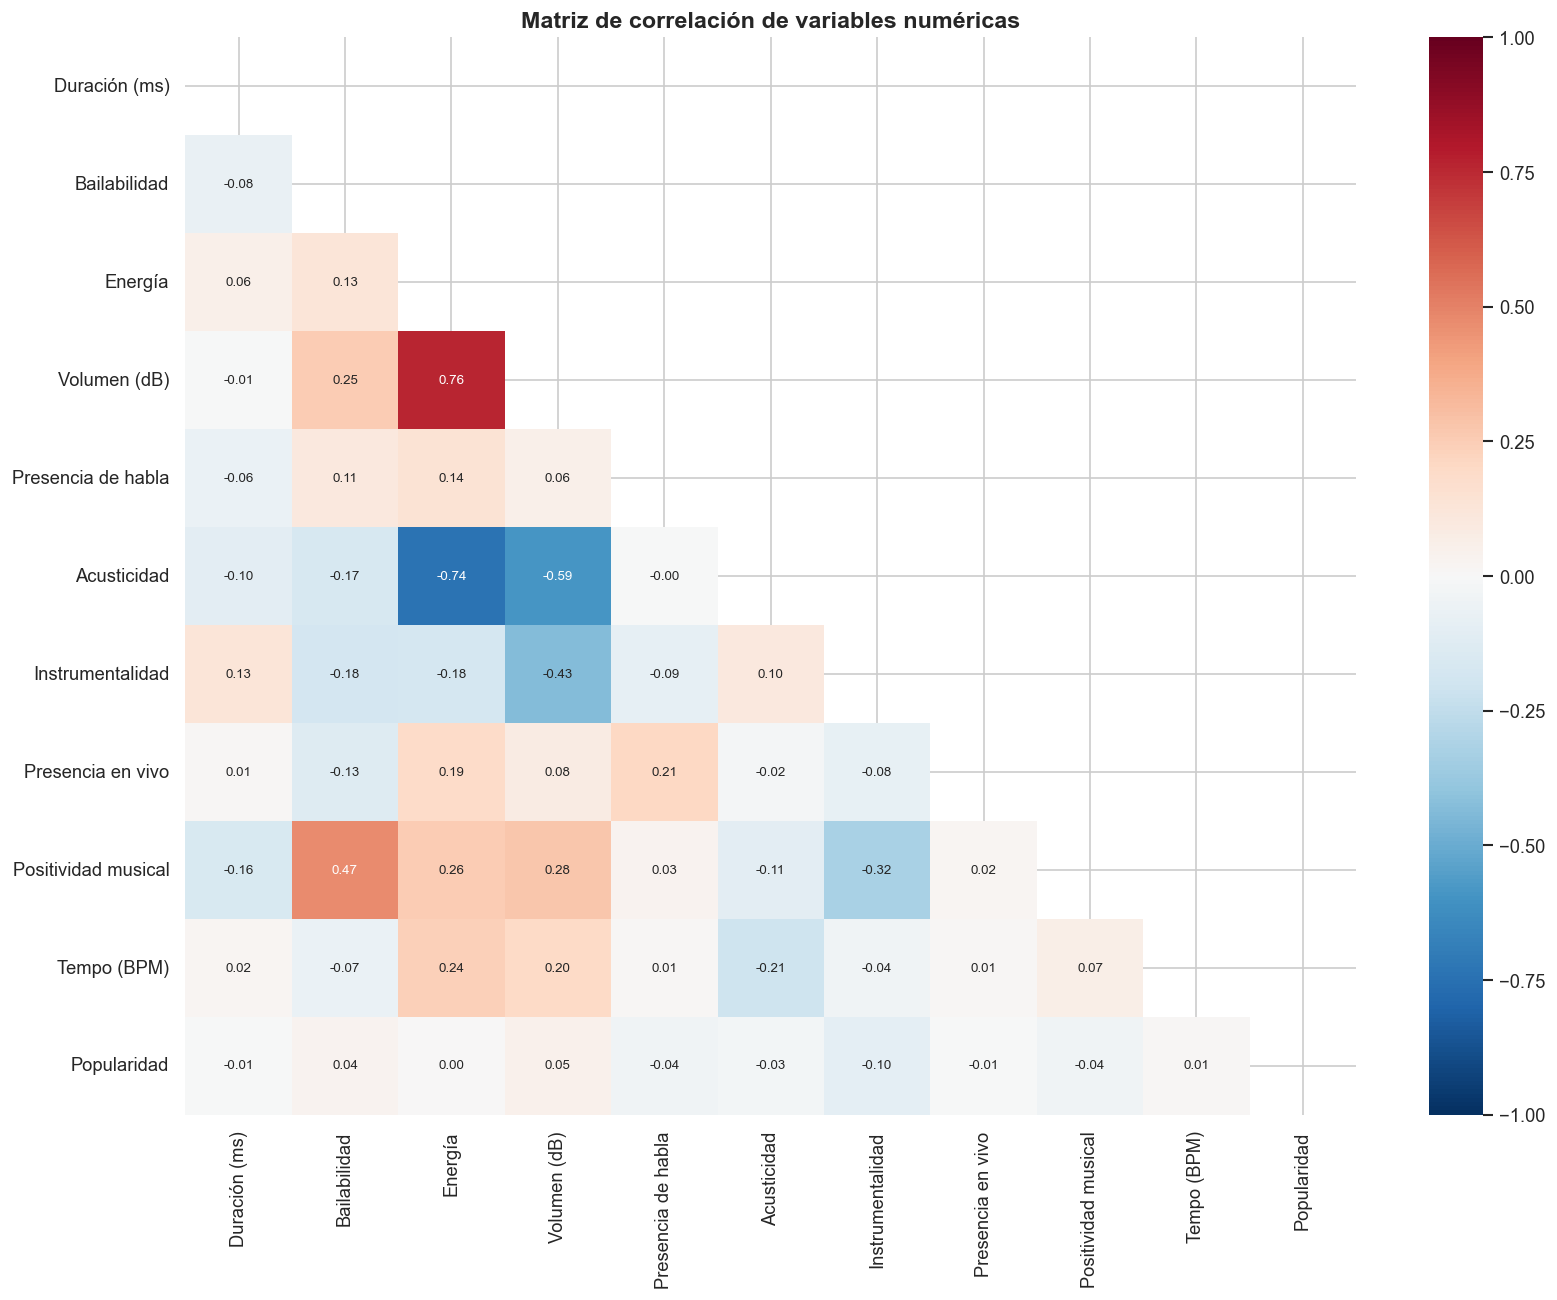

=== Correlaciones con popularidad (ordenadas por valor absoluto) ===


,correlacion_con_popularidad
instrumentalidad,-0.0959
volumen_db,0.0515
presencia_habla,-0.0448
positividad,-0.0402
bailabilidad,0.0365
acusticidad,-0.0256
tempo_bpm,0.0144
duracion_ms,-0.0070
presencia_en_vivo,-0.0057
energia,0.0015


Correlaciones con |r| >= 0.10: 0 de 10 calculables.
La correlación describe asociación lineal, no causalidad ni desempeño del modelo.


In [17]:
corr_cols = audio_numericas + ['popularidad']
corr = df_limpio[corr_cols].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr.rename(index=ETIQUETAS, columns=ETIQUETAS), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de correlación de variables numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '03_matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlaciones con popularidad
corr_pop = corr['popularidad'].drop('popularidad').sort_values(key=lambda s: s.abs(), ascending=False)
print('=== Correlaciones con popularidad (ordenadas por valor absoluto) ===')
display(corr_pop.to_frame('correlacion_con_popularidad').round(4))
print(f'Correlaciones con |r| >= 0.10: {corr_pop.abs().ge(0.10).sum()} de {corr_pop.notna().sum()} calculables.')
print('La correlación describe asociación lineal, no causalidad ni desempeño del modelo.')


### 3.8 Popularidad por grupos

In [18]:
# Por género
estadisticas_genero = (
    df_limpio.groupby('genero_musical')
    .agg(
        n               = ('id_cancion', 'size'),
        popularidad_media = ('popularidad', 'mean'),
        popularidad_mediana  = ('popularidad', 'median'),
        popularidad_desviacion  = ('popularidad', 'std'),
        bailabilidad_media      = ('bailabilidad', 'mean'),
        energia_media     = ('energia', 'mean')
    )
    .sort_values('popularidad_media', ascending=False)
    .round(2)
)

print('=== 10 primeros géneros por popularidad media ===')
display(estadisticas_genero.head(10))
print('\n=== 10 últimos géneros por popularidad media ===')
display(estadisticas_genero.tail(10))

estadisticas_genero.to_csv(PROCESSED_DIR / 'genre_popularity_stats.csv')


=== 10 primeros géneros por popularidad media ===


,n,popularidad_media,popularidad_mediana,popularidad_desviacion,bailabilidad_media,energia_media
genero_musical,,,,,,
pop-film,1000,59.2800,60.0000,10.2500,0.6000,0.6000
k-pop,999,56.9500,60.0000,16.8600,0.6500,0.6800
chill,1000,53.6500,57.0000,14.9500,0.6600,0.4300
sad,1000,52.3800,54.0000,11.4900,0.6900,0.4600
grunge,1000,49.5900,55.0000,18.4900,0.4600,0.8000
indian,1000,49.5400,49.0000,11.3500,0.5900,0.5700
anime,1000,48.7700,50.0000,11.8100,0.5400,0.6700
emo,1000,48.1300,51.0000,17.5900,0.6000,0.6700
sertanejo,1000,47.8700,47.0000,3.9400,0.5900,0.7100



=== 10 últimos géneros por popularidad media ===


,n,popularidad_media,popularidad_mediana,popularidad_desviacion,bailabilidad_media,energia_media
genero_musical,,,,,,
idm,1000,15.7700,12.0000,10.2700,0.5300,0.5600
kids,1000,14.8900,12.0000,9.2400,0.7800,0.6100
grindcore,1000,14.6200,14.0000,4.5000,0.2700,0.9200
jazz,999,13.5800,0.0000,23.1400,0.5100,0.3500
classical,1000,13.0600,3.0000,18.0900,0.3800,0.1900
chicago-house,1000,12.3400,10.0000,9.5800,0.7700,0.7300
detroit-techno,1000,11.1700,8.0000,8.9500,0.7200,0.7100
latin,1000,8.3000,0.0000,21.9600,0.7200,0.7300
romance,999,3.2200,0.0000,6.2600,0.4300,0.2900


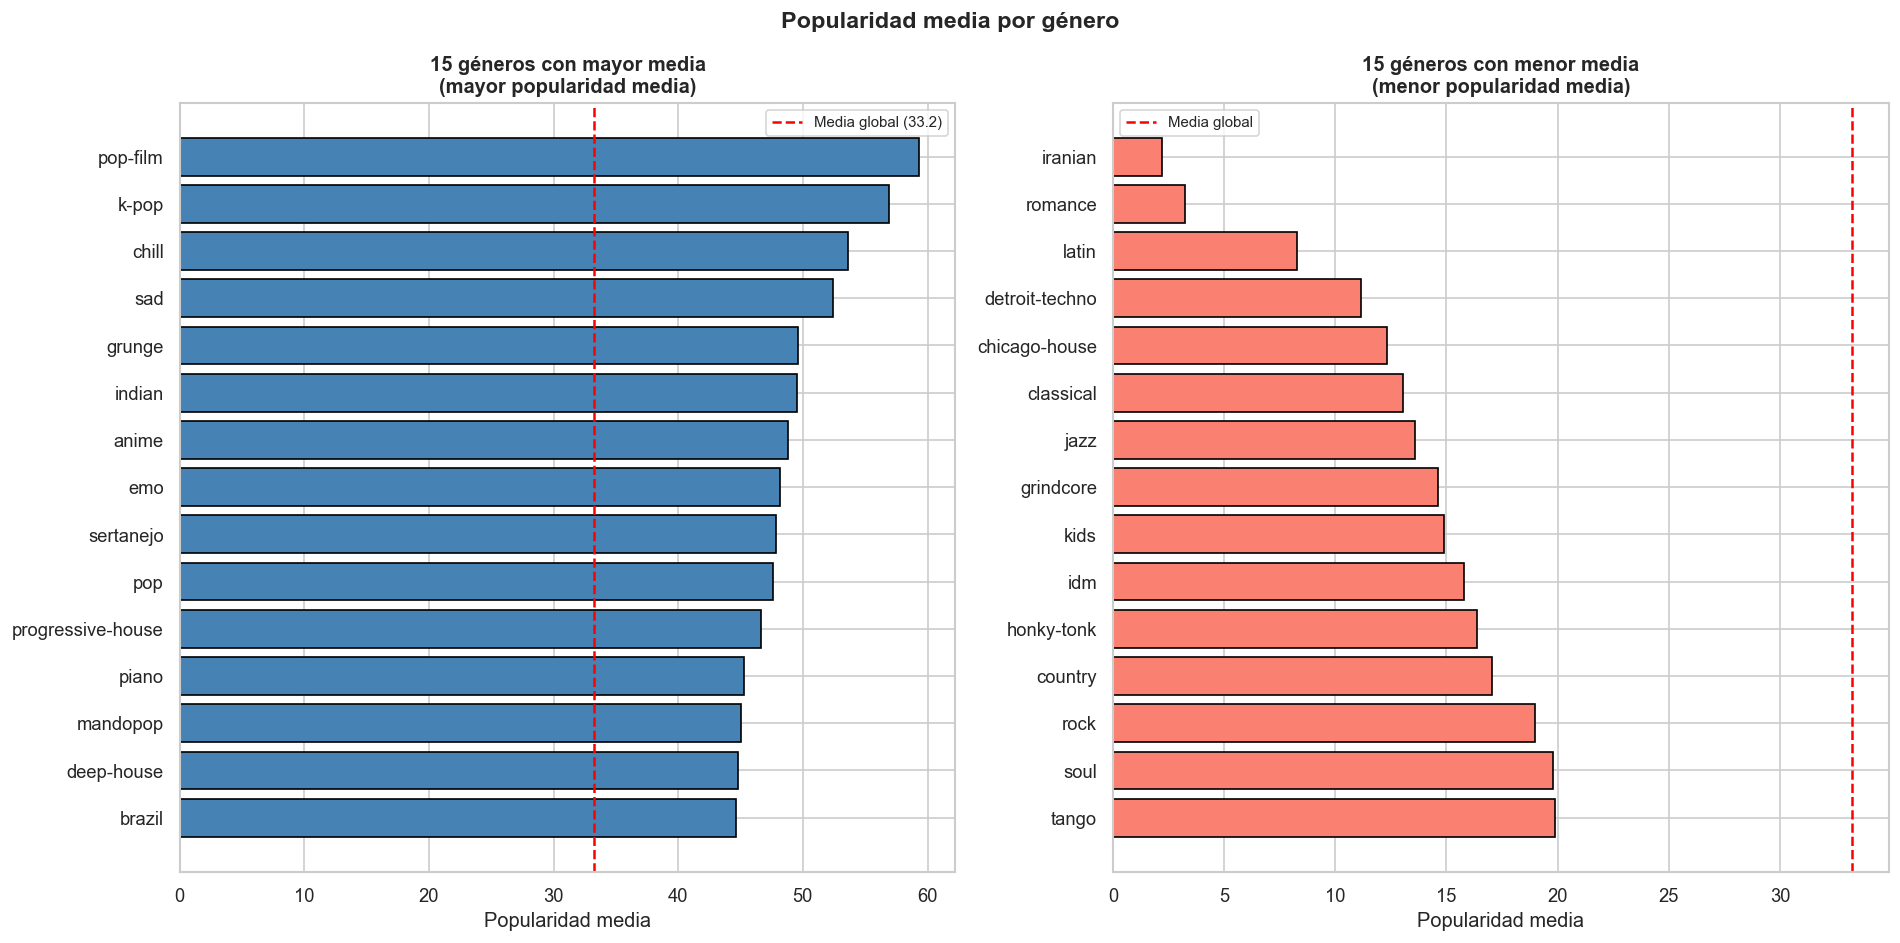

In [19]:
# Gráfico Top 15 y Bottom 15
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

top15  = estadisticas_genero.head(15).sort_values('popularidad_media')
bot15  = estadisticas_genero.tail(15).sort_values('popularidad_media', ascending=False)

ax1.barh(top15.index, top15['popularidad_media'], color='steelblue', edgecolor='black')
ax1.set_title('15 géneros con mayor media\n(mayor popularidad media)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Popularidad media')
ax1.axvline(df_limpio['popularidad'].mean(), color='red', linestyle='--', label=f'Media global ({df_limpio["popularidad"].mean():.1f})')
ax1.legend(fontsize=9)

ax2.barh(bot15.index, bot15['popularidad_media'], color='salmon', edgecolor='black')
ax2.set_title('15 géneros con menor media\n(menor popularidad media)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Popularidad media')
ax2.axvline(df_limpio['popularidad'].mean(), color='red', linestyle='--', label=f'Media global')
ax2.legend(fontsize=9)

plt.suptitle('Popularidad media por género', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '04_popularidad_por_genero.png', dpi=150, bbox_inches='tight')
plt.show()


=== Popularidad según contenido explícito ===


,cantidad,media,mediana,desviacion_estandar
contenido_explicito,,,,
False,104095,32.9300,34.0000,22.1000
True,9747,36.4500,37.0000,24.3200


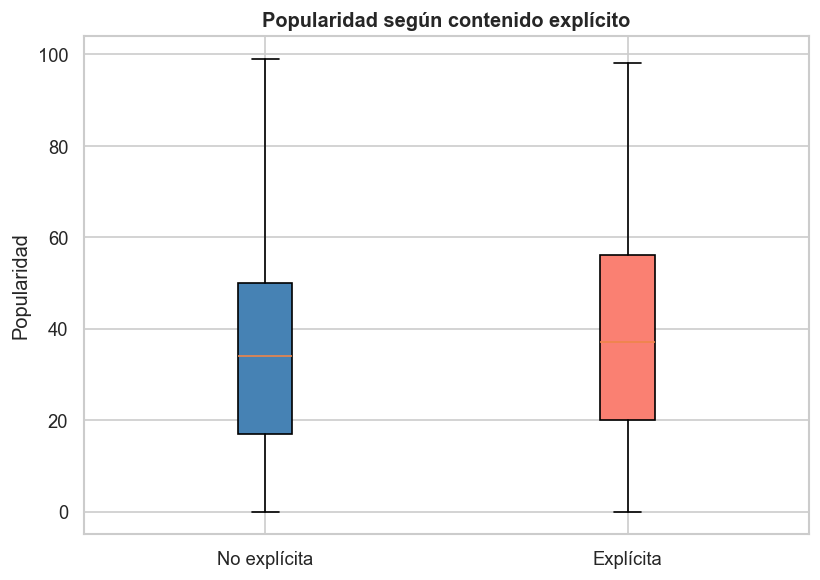

Diferencia de medias: 3.52 puntos (no implica causalidad)


In [20]:
# Por contenido_explicito
estadisticas_explicito = df_limpio.groupby('contenido_explicito')['popularidad'].agg(['count','mean','median','std']).round(2)
print('=== Popularidad según contenido explícito ===')
display(estadisticas_explicito.rename(columns={'count': 'cantidad', 'mean': 'media', 'median': 'mediana', 'std': 'desviacion_estandar'}))

fig, ax = plt.subplots(figsize=(7, 5))
groups_data = [df_limpio.loc[df_limpio['contenido_explicito'] == False, 'popularidad'].values,
               df_limpio.loc[df_limpio['contenido_explicito'] == True,  'popularidad'].values]
bp = ax.boxplot(groups_data, positions=[1, 2], patch_artist=True,
                showfliers=False)
ax.set_xticks([1, 2], ['No explícita', 'Explícita'])
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('salmon')
ax.set_title('Popularidad según contenido explícito', fontsize=12, fontweight='bold')
ax.set_ylabel('Popularidad')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '05_popularidad_explicit.png', dpi=150, bbox_inches='tight')
plt.show()
if {False, True}.issubset(estadisticas_explicito.index):
    print('Diferencia de medias: {:.2f} puntos (no implica causalidad)'.format(
        estadisticas_explicito.loc[True, 'mean'] - estadisticas_explicito.loc[False, 'mean']))


### 3.9 Perfil de canciones populares

Se comparan los features de audio entre canciones con popularidad ≥ 70 y el resto.


In [21]:
pop_alta  = df_limpio[df_limpio['popularidad'] >= 70]
pop_baja  = df_limpio[df_limpio['popularidad'] < 70]

print(f'Canciones con popularidad >= 70: {len(pop_alta):,} ({len(pop_alta)/len(df_limpio)*100:.1f}%)')
print(f'Resto: {len(pop_baja):,}')

comparacion = pd.DataFrame({
    'Popular (≥70)':   pop_alta[audio_numericas].mean(),
    'Resto (<70)':     pop_baja[audio_numericas].mean(),
}).round(4)
comparacion['Diferencia'] = (comparacion['Popular (≥70)'] - comparacion['Resto (<70)']).round(4)
display(comparacion)
print('Comparar las diferencias calculadas arriba; no implican causalidad.')


Canciones con popularidad >= 70: 5,470 (4.8%)
Resto: 108,372


,Popular (≥70),Resto (<70),Diferencia
duracion_ms,"218,501.2808","228,593.5853","-10,092.3045"
bailabilidad,0.6163,0.5651,0.0512
energia,0.6713,0.6406,0.0307
volumen_db,-6.6550,-8.3199,1.6649
presencia_habla,0.0753,0.0852,-0.0099
acusticidad,0.2210,0.3194,-0.0984
instrumentalidad,0.0363,0.1614,-0.1251
presencia_en_vivo,0.1720,0.2153,-0.0433
positividad,0.5047,0.4732,0.0315
tempo_bpm,120.1775,122.4241,-2.2466


Comparar las diferencias calculadas arriba; no implican causalidad.


### 3.10 Pipeline de preparación para Machine Learning

- **Objetivo:** popularidad; excluir identificadores, metadatos de alta cardinalidad
  y duracion_min por duplicar duracion_ms.
- **Numéricas:** StandardScaler, sensible a valores extremos. No es un escalador robusto.
- **Compás:** SimpleImputer(strategy='most_frequent') y OneHotEncoder.
- **Otras categóricas:** OneHotEncoder(handle_unknown='ignore').
- **Partición:** reutilizar los índices por id_cancion reservados en la subsección 3.1.
  La fracción de prueba es 20% de los grupos, no necesariamente 20% exacto de filas.
- **Sin fuga de información:** el pipeline recibe df_base, con compás sin imputar,
  y aprende exclusivamente de entrenamiento. El conjunto de prueba no decide la moda.

En EP2, mantener la imputación dentro del pipeline en cada pliegue de validación
por grupos. No usar spotify_clean.csv ya imputado para ajustar de nuevo una
validación cruzada. El EDA completo es descriptivo: no usar hallazgos del conjunto
de prueba para seleccionar modelos ni variables.


**Nota metodológica — encoding vs. fuga de información**

Es importante no confundir dos problemas distintos que este proyecto resuelve por separado:

1. **Codificación de variables categóricas** (`OneHotEncoder` sobre `genero_musical`, `tonalidad`, `modo`, `compas`, `contenido_explicito`): sirve para convertir categorías en columnas numéricas que un modelo pueda procesar. No tiene relación con la partición train/test.
2. **Fuga de información por canciones repetidas entre géneros** (16.641 `id_cancion` aparecen en más de un género): este problema se resuelve exclusivamente con `GroupShuffleSplit` agrupando por `id_cancion` (ver celda de partición más abajo), que garantiza que una misma canción no caiga en train y test a la vez.

Agregar más columnas one-hot **no reduce ni previene la fuga de información por ID** — one-hot encoding expande la representación de las categorías, pero no controla qué filas van a cada partición. La partición por grupos (`GroupShuffleSplit`) ya implementada es la técnica correcta para este problema y se mantiene sin cambios.


In [22]:
model_numeric = audio_numericas.copy()
model_categorical = ['contenido_explicito', 'tonalidad', 'modo', 'compas', 'genero_musical']
otras_categoricas = [c for c in model_categorical if c != 'compas']

# Usar la base que todavía conserva NaN en compás, no la exportación imputada.
X = df_base[model_numeric + model_categorical].copy()
y = df_base['popularidad'].copy()
groups = df_base['id_cancion'].copy()
X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
train_ids, test_ids = set(groups.iloc[train_idx]), set(groups.iloc[test_idx])
overlap = train_ids & test_ids
assert not overlap, 'Existe fuga de información por ID de canción.'
assert len(X_train) + len(X_test) == len(df_base)
print(f'Entrenamiento: {X_train.shape}; prueba: {X_test.shape}')
print(f'ID de canción compartidos: {len(overlap)}')


Entrenamiento: (91072, 15); prueba: (22770, 15)
ID de canción compartidos: 0


In [23]:
transformador_compas = Pipeline([
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('codificador', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer(transformers=[
    ('numericas', StandardScaler(), model_numeric),
    ('categoricas', OneHotEncoder(handle_unknown='ignore', sparse_output=False), otras_categoricas),
    ('compas', transformador_compas, ['compas']),
])

# Ajuste SOLO en entrenamiento. En esta versión no se entrena un predictor.
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
moda_pipeline = int(preprocessor.named_transformers_['compas'].named_steps['imputador'].statistics_[0])
moda_limpieza = int(balance_limpieza.loc[
    balance_limpieza['indicador'].eq('moda_compas_entrenamiento'), 'cantidad'
].iloc[0])
assert moda_pipeline == moda_limpieza, 'La imputación debe coincidir con la moda reservada.'
assert np.isfinite(X_train_prep).all() and np.isfinite(X_test_prep).all()
assert X_train_prep.shape[1] == X_test_prep.shape[1]
nombres_preparados = preprocessor.get_feature_names_out()
pd.DataFrame({'variable_transformada': nombres_preparados}).to_csv(
    PROCESSED_DIR / 'variables_modelo.csv', index=False
)
print(f'Moda del compás aprendida solo con entrenamiento: {moda_pipeline}')
print(f'Matriz de entrenamiento: {X_train_prep.shape}')
print(f'Matriz de prueba: {X_test_prep.shape}')
print('Verificado: matrices sin nulos ni infinitos y sin canciones compartidas entre conjuntos.')


Moda del compás aprendida solo con entrenamiento: 4
Matriz de entrenamiento: (91072, 144)
Matriz de prueba: (22770, 144)
Verificado: matrices sin nulos ni infinitos y sin canciones compartidas entre conjuntos.


In [24]:
# 3.11.a Cuantificación del sesgo por género en la regla "cero en audio"
eliminadas_por_cero_audio = filas_descartadas[filas_descartadas['motivo_cero_en_audio']]
impacto_genero = (
    eliminadas_por_cero_audio['genero_musical']
    .value_counts()
    .rename('filas_eliminadas')
    .to_frame()
)
impacto_genero['pct_del_total_eliminado'] = (
    100 * impacto_genero['filas_eliminadas'] / eliminadas_por_cero_audio.shape[0]
).round(2)
display(impacto_genero.head(10))
print(f'Total de filas eliminadas por la regla de audio en cero: {len(eliminadas_por_cero_audio)}')
print(f"Género con mayor impacto: {impacto_genero.index[0]} "
      f"({impacto_genero.iloc[0]['pct_del_total_eliminado']}% del total eliminado)")

,filas_eliminadas,pct_del_total_eliminado
genero_musical,,
sleep,138,87.9000
iranian,4,2.5500
guitar,4,2.5500
ambient,3,1.9100
world-music,3,1.9100
opera,2,1.2700
jazz,1,0.6400
show-tunes,1,0.6400
romance,1,0.6400


Total de filas eliminadas por la regla de audio en cero: 157
Género con mayor impacto: sleep (87.9% del total eliminado)


### 3.11 Sesgos, ética y privacidad

| Riesgo o sesgo | Tipo | Medida de control |
|---|---|---|
| Eliminación de ceros de audio afecta desproporcionadamente al género `sleep` | **Observado** (ver celda anterior) | El 87.9% de las filas eliminadas por la regla de audio en cero pertenece a un solo género. Se documenta en vez de tratarse como neutral; en EP2 se debe evaluar si esta pérdida diferencial afecta el desempeño del modelo específicamente en ese género. |
| Exposición desigual por género en el futuro modelo | Potencial | Evaluar MAE y RMSE por género en EP2, no solo de forma global. |
| **Representación multi-género:** una canción asociada a varios géneros queda sobrerrepresentada al mantener una fila por género | **Observado** (16.641 canciones, ver celda siguiente) | Partición por `id_cancion` (no por fila) ya evita la fuga de información entre train y test. Como mejora adicional, se propone y se implementa a continuación una representación alternativa **1 canción = 1 observación**, con los géneros codificados en formato multi-hot, para EP2. |
| Popularidad cambiante en el tiempo | Metodológico | Documentar la fecha de extracción cuando esté disponible; el CSV no la declara. |
| Ciclo de retroalimentación algorítmica | Potencial | Mantener supervisión humana y no tratar la predicción como sinónimo de calidad artística. |

**Propiedad intelectual y licenciamiento de los datos**

- El dataset proviene de Kaggle bajo licencia de uso académico/no comercial; **no se distribuyen archivos de audio**, solo metadatos y atributos numéricos derivados. Cualquier uso más allá del ámbito académico de esta evaluación requeriría revisar la licencia original y los Términos de Servicio de la API de Spotify.
- Los metadatos de artistas, álbumes y canciones son información pública, pero **no constituyen cesión de derechos de autor** sobre las obras musicales. El proyecto no reproduce, distribuye ni comercializa contenido protegido: solo analiza atributos numéricos derivados (tempo, energía, etc.), no las obras en sí.
- Un eventual modelo entrenado con estos datos, si se llevara a producción, debería documentar la fuente y licencia de los datos de entrenamiento como parte de su trazabilidad (data lineage), especialmente si se usa para decisiones comerciales de promoción o contratos.

**Privacidad:** el dataset no contiene historiales ni perfiles de usuarios individuales, solo metadatos públicos de canciones. El riesgo de privacidad individual es bajo. Si se incorporaran datos de usuarios (historial de reproducción, ubicación), aplicarían principios de minimización de datos y la normativa de protección de datos personales correspondiente.

#### 3.11.b Mejora propuesta: representación multi-género (1 canción = 1 observación)

**Riesgo actual:** el dataset limpio (`df_limpio`) mantiene una fila por combinación
canción-género. Una canción asociada a varios géneros puede quedar sobrerrepresentada
en el análisis y en un futuro entrenamiento si se mantiene esa estructura — no porque
la partición train/test esté mal hecha (ya se resolvió con `GroupShuffleSplit`), sino
porque el propio conteo de filas por canción deja de ser 1:1 con las canciones reales.

**Mejora propuesta:** transformar la representación a **1 canción = 1 observación**,
codificando sus géneros mediante **multi-hot encoding** (una columna binaria por
género, en vez de una fila por género). Además de evitar redundancia, esta
representación reduce el riesgo de que ciertas canciones tengan mayor peso solamente
por pertenecer a múltiples categorías.

In [25]:
# 3.11.c Construcción de la representación multi-género (demostración, para EP2)
from sklearn.preprocessing import MultiLabelBinarizer

cols_atributos_cancion = [
    'artistas', 'nombre_album', 'nombre_cancion', 'duracion_ms',
    'contenido_explicito', 'bailabilidad', 'energia', 'tonalidad',
    'volumen_db', 'modo', 'presencia_habla', 'acusticidad',
    'instrumentalidad', 'presencia_en_vivo', 'positividad', 'tempo_bpm', 'compas',
]

# Verificación: ¿varían los atributos de audio entre las filas duplicadas de una misma canción?
duplicadas = df_limpio[df_limpio.duplicated('id_cancion', keep=False)]
variacion = duplicadas.groupby('id_cancion')[
    ['bailabilidad', 'energia', 'volumen_db', 'tempo_bpm', 'popularidad']
].nunique()
con_audio_distinto = (variacion[['bailabilidad', 'energia', 'volumen_db', 'tempo_bpm']] > 1).any(axis=1).sum()
con_popularidad_distinta = (variacion['popularidad'] > 1).sum()
print(f'Canciones duplicadas con algún atributo de AUDIO distinto entre géneros: '
      f'{con_audio_distinto} de {len(variacion)} (deberían ser 0: es la misma grabación).')
print(f'Canciones duplicadas con POPULARIDAD distinta entre géneros: '
      f'{con_popularidad_distinta} de {len(variacion)} (se resuelve con la mediana al agrupar).')

# Un valor representativo por canción para atributos de audio (constantes por grabación)
# y la mediana de popularidad (robusta ante la pequeña variación detectada arriba).
atributos_por_cancion = df_limpio.groupby('id_cancion').agg(
    {**{c: 'first' for c in cols_atributos_cancion}, 'popularidad': 'median'}
)

# Lista de géneros por canción, y codificación multi-hot
generos_por_cancion = df_limpio.groupby('id_cancion')['genero_musical'].apply(lambda s: sorted(set(s)))
mlb = MultiLabelBinarizer()
generos_multihot = pd.DataFrame(
    mlb.fit_transform(generos_por_cancion),
    columns=mlb.classes_,
    index=generos_por_cancion.index,
)

df_multigenero = atributos_por_cancion.join(generos_multihot).reset_index()
df_multigenero.to_csv(PROCESSED_DIR / 'spotify_multigenero.csv', index=False)

print(f'\nFilas antes (1 fila por combinación canción-género): {len(df_limpio):,}')
print(f'Filas después (1 fila por canción):                    {len(df_multigenero):,}')
print(f'Columnas de género generadas (multi-hot):               {len(mlb.classes_)}')
print(f'Guardado en: {PROCESSED_DIR / "spotify_multigenero.csv"}')

# Ejemplo con una canción que pertenece a varios géneros
ejemplo_id = generos_por_cancion[generos_por_cancion.apply(len) >= 3].index[0]
generos_ejemplo = generos_por_cancion[ejemplo_id][:3]
columnas_ejemplo = ['id_cancion', 'nombre_cancion'] + generos_ejemplo + ['pop', 'rock']
columnas_ejemplo = list(dict.fromkeys(columnas_ejemplo))  # sin duplicados, preserva orden
print('\nEjemplo — una canción, varios géneros, una sola fila:')
display(df_multigenero.loc[df_multigenero['id_cancion'] == ejemplo_id, columnas_ejemplo])


Canciones duplicadas con algún atributo de AUDIO distinto entre géneros: 0 de 16641 (deberían ser 0: es la misma grabación).
Canciones duplicadas con POPULARIDAD distinta entre géneros: 720 de 16641 (se resuelve con la mediana al agrupar).

Filas antes (1 fila por combinación canción-género): 113,842
Filas después (1 fila por canción):                    89,583
Columnas de género generadas (multi-hot):               114
Guardado en: c:\Users\aleee\Downloads\machine-learning-spotify\data\processed\spotify_multigenero.csv

Ejemplo — una canción, varios géneros, una sola fila:


,id_cancion,nombre_cancion,alt-rock,alternative,rock,pop
12,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,1,1,1,0


**Nota de alcance:** esta representación queda **construida, verificada y guardada**
(`data/processed/spotify_multigenero.csv`) como mejora propuesta para EP2. El
pipeline de preparación de la sección 3.10 y el target de clasificación de la
sección 3.12 **no se modifican** en esta entrega — siguen usando la representación
de una fila por canción-género con partición por `id_cancion`, que ya está
verificada y sin fuga de información. Adoptar `spotify_multigenero.csv` como base
del modelamiento es una decisión de diseño para EP2, no de esta EP1.

### 3.12 Definición del target de clasificación (preparación para EP2)

En la sección 3.7 se observó que ninguna variable de audio individual supera
|r| = 0.10 de correlación lineal con `popularidad`. Esa correlación débil hace poco
confiable un modelo de **regresión lineal simple** sobre el valor continuo de
popularidad, ya que este tipo de modelo depende de relaciones lineales fuertes con
las variables predictoras para generalizar bien.

Por eso, se define desde ahora — como parte de la preparación de datos — el target
que se usará para el modelamiento en EP2: `popularidad` reformulada en tres clases
(**bajo / medio / alto**), en lugar de un valor numérico continuo. Esta definición se
hace aquí, y no en Fase 4, porque construir el target y verificar que no haya fuga de
información es preparación de datos, no modelamiento — todavía no se entrena ni se
evalúa ningún modelo en esta entrega.

In [26]:
# 3.12.a Construcción del target categórico (bajo / medio / alto)
# Los cortes se aprenden SOLO con el conjunto de entrenamiento, para no filtrar
# información de prueba en la definición de las clases. No se entrena ningún
# modelo en esta celda: solo se prepara el target para EP2.
bordes_popularidad = y_train.quantile([0, 1/3, 2/3, 1]).to_numpy(copy=True)
bordes_popularidad[0], bordes_popularidad[-1] = -0.1, 100.1
etiquetas_clase = ['bajo', 'medio', 'alto']

y_train_clase = pd.cut(y_train, bins=bordes_popularidad, labels=etiquetas_clase, include_lowest=True)
y_test_clase = pd.cut(y_test, bins=bordes_popularidad, labels=etiquetas_clase, include_lowest=True)

assert y_test_clase.isna().sum() == 0, 'Hay valores de prueba fuera de los bordes aprendidos en train.'

print('Bordes de popularidad aprendidos en entrenamiento (tercios):', bordes_popularidad.round(1))
print('\nDistribución de clases en entrenamiento:')
display(y_train_clase.value_counts())
print('\nDistribución de clases en prueba:')
display(y_test_clase.value_counts())
print('\nTarget preparado y guardado en memoria (y_train_clase, y_test_clase) para EP2.')
print('No se entrena ningún modelo en esta entrega.')


Bordes de popularidad aprendidos en entrenamiento (tercios): [-1.000e-01  2.200e+01  4.500e+01  1.001e+02]

Distribución de clases en entrenamiento:


popularidad
bajo     31138
medio    30933
alto     29001
Name: count, dtype: int64


Distribución de clases en prueba:


popularidad
bajo     7726
medio    7627
alto     7417
Name: count, dtype: int64


Target preparado y guardado en memoria (y_train_clase, y_test_clase) para EP2.
No se entrena ningún modelo en esta entrega.


### Modelo propuesto para evaluaciones futuras: `RandomForestClassifier`

Se deja documentada, sin entrenar todavía, la elección de modelo para la siguiente
entrega:

- **Por qué clasificación y no regresión:** las correlaciones lineales individuales
  entre variables de audio y `popularidad` son débiles (sección 3.7), lo que hace
  poco confiable un modelo lineal sobre el valor continuo. Reformular el problema
  como clasificación en tres niveles (bajo/medio/alto) es más robusto ante esa
  falta de señal lineal fuerte y entrega un resultado directamente accionable para
  decisiones editoriales (ej. "priorizar para playlist de alta rotación").
- **Por qué `RandomForestClassifier` y no un modelo lineal (ej. regresión logística):**
  es un modelo no lineal basado en árboles, capaz de capturar interacciones entre
  variables (por ejemplo, combinaciones de género + energía + acusticidad) sin
  requerir supuestos de linealidad ni de distribución normal de los residuos —
  justamente el tipo de estructura que la matriz de correlaciones lineales no
  puede detectar.
- **Qué falta para evaluaciones futuras:** entrenar `RandomForestClassifier` sobre `X_train_prep` /
  `y_train_clase`, compararlo contra un baseline de clase mayoritaria, y evaluar
  con accuracy y F1 macro sobre `X_test_prep` / `y_test_clase` — datos que ya
  quedan preparados y sin fuga de información desde esta entrega.

## Conclusiones Fase 3

## Fase 4: Modeling

**Estado:** reservado para EP2. En esta entrega no se entrena ningún modelo;
la sección 3.12 ya deja preparados y documentados el target de clasificación
(`y_train_clase`, `y_test_clase`) y la elección de modelo (`RandomForestClassifier`),
justificada por la baja correlación lineal de las variables con `popularidad`.

In [27]:
# EP2: entrenar RandomForestClassifier (y un baseline de clase mayoritaria)
# dentro de un pipeline reproducible, usando y_train_clase / y_test_clase
# ya preparados en la sección 3.12. No se ejecuta modelamiento en esta EP1.

### Aprendizaje Supervisado — Regresión

Se descarta como enfoque principal: la correlación lineal individual de las
variables con `popularidad` es débil (sección 3.7), por lo que se prioriza la
clasificación (ver 3.12). No se entrena ni evalúa un modelo de regresión en
esta entrega.

In [28]:
# No aplica: se descartó el enfoque de regresión en favor de clasificación (ver 3.12).

### Aprendizaje Supervisado — Clasificación

Target y modelo ya definidos en 3.12 (`popularidad` → bajo/medio/alto,
`RandomForestClassifier`). El entrenamiento se realiza en EP2.

In [29]:
# EP2: entrenar RandomForestClassifier sobre X_train_prep / y_train_clase
# y comparar contra baseline de clase mayoritaria.

## Fase 5: Evaluation

In [30]:
# EP2: calcular accuracy y F1 macro sobre X_test_prep / y_test_clase,
# no utilizados en el ajuste, y comparar contra el baseline.

### Aprendizaje Supervisado — Regresión

No aplica: se descartó este enfoque en 3.12.

#### Comparación final
No corresponde comparar modelos de regresión en esta entrega.

### Aprendizaje Supervisado — Clasificación

La evaluación futura utilizará **accuracy** y **F1 macro** sobre
`RandomForestClassifier` vs. el baseline de clase mayoritaria, además de matriz
de confusión y desempeño desagregado por género musical (para verificar si el
sesgo documentado en 3.11 se traduce en peor desempeño del modelo).

#### Comparación final
Pendiente hasta entrenar y evaluar el modelo en EP2. No se presentan métricas
inventadas ni obtenidas a partir del conjunto de prueba durante la preparación.

### Conclusión de evaluación

El pipeline y el target de clasificación fueron verificados para producir
matrices y etiquetas compatibles, sin nulos, sin infinitos y sin fuga de
información por `id_cancion`. Esta comprobación valida la preparación técnica,
pero **no constituye una evaluación del rendimiento predictivo** — eso queda
para EP2.

### Aprendizaje no supervisado — Clustering

No forma parte del objetivo de esta EP1. Podría explorarse en otra etapa para
analizar perfiles musicales, sin reemplazar la evaluación del modelo de
clasificación.

## Fase 6: Deployment

**Estado:** trabajo futuro.